# Quantum Fast Weight Programmers (QFWP)
## A Hands-on Tutorial with GPU Simulation and CPU–GPU Benchmarking

**Samuel Yen-Chi Chen**

### Background and Original Work

This tutorial is based on my original paper:

> Samuel Yen-Chi Chen, **“Learning to Program Variational Quantum Circuits with Fast Weights,”** *2024 International Joint Conference on Neural Networks (IJCNN)*, presented as part of IEEE WCCI 2024.  
> DOI: [10.1109/IJCNN60899.2024.10650743](https://doi.org/10.1109/IJCNN60899.2024.10650743)

**[Read the paper on arXiv](https://arxiv.org/abs/2402.17760)** · **[Original public QFWP implementation on GitHub](https://github.com/ycchen1989/Quantum_FWP)**

Quantum Fast Weight Programmers combine a classical **slow programmer** with a variational quantum circuit whose parameters serve as **fast weights**. At each time step, the slow programmer generates an update to the circuit parameters. Accumulating these updates allows the model to retain information from previous observations and learn temporal dependencies.

### What This Notebook Adds

This notebook provides an **updated and extended implementation of the original QFWP**, designed for hands-on demonstrations in Google Colab. It preserves the core model and additive fast-weight update mechanism while extending the implementation and experimental workflow:

- **A notebook-based learning workflow:** step-by-step data preparation, model construction, gradient checks, training, and visualization for a time-series prediction example.
- **GPU simulation support:** integration with PennyLane’s `lightning.gpu` backend, powered by NVIDIA cuQuantum/cuStateVec, while retaining CPU execution options.
- **CPU–GPU scaling benchmarks:** comparisons of training forward-call time, backward-call time, and their combined time across different numbers of qubits, using `lightning.qubit` and `lightning.gpu` with adjoint differentiation.

The objective is to demonstrate how the original QFWP implementation can be adapted to different simulation backends and to investigate **when, and to what extent, GPU simulation benefits this workload**. These are implementation and benchmarking extensions, not a new QFWP architecture or a claim of improved predictive accuracy.

### How to Interpret the Benchmarks

The benchmarks measure a **complete QFWP minibatch over an input sequence**, including the classical slow programmer, fast-weight updates, quantum-circuit evaluations, and classical readout. They do not measure an isolated quantum gate or circuit.

With the benchmark’s adjoint-on-execution configuration, quantum Jacobians may be computed during the training forward call. Consequently, **forward time is not pure inference time**, and backward time alone does not represent the full cost of computing gradients. The combined **forward + backward** time is the primary comparison metric; optimizer updates are excluded.

Both backends simulate quantum circuits on classical hardware. Any observed speedup therefore concerns **GPU versus CPU simulation**, not quantum computational advantage. Results depend on the hardware, software environment, circuit size, and benchmark configuration.

### Citation

Please cite the original paper when using QFWP in your research:

```bibtex
@inproceedings{chen2024learning,
  author    = {Chen, Samuel Yen-Chi},
  title     = {Learning to Program Variational Quantum Circuits with Fast Weights},
  booktitle = {2024 International Joint Conference on Neural Networks (IJCNN)},
  year      = {2024},
  doi       = {10.1109/IJCNN60899.2024.10650743},
  url       = {https://arxiv.org/abs/2402.17760}
}
```

**Technical documentation:** [PennyLane Lightning GPU](https://docs.pennylane.ai/projects/lightning/en/stable/lightning_gpu/device.html) · [PennyLane QNode execution and differentiation options](https://docs.pennylane.ai/en/stable/code/api/pennylane.QNode.html)

# Quantum Fast Weight Programmers
### PennyLane × NVIDIA cuQuantum — Colab Tutorial Demo

**The same QFWP model: switch the simulation backend without changing the fast-weight learning rule.**

$$\Theta_t = \Theta_{t-1} + \ell_t q_t^\mathsf{T}, \qquad
\hat y_t = W_{\rm out}\,\langle Z\rangle_{U(x_t,\Theta_t)} + b_{\rm out}.$$

This notebook embeds both Python modules. No separate `.py` uploads, Google Drive mount,
or dataset download is required. It preserves the original `nn.Parameter` implementation,
quantum circuit, additive outer-product update, ODE, and windowing convention.

**Scope:** backend integration and a short training demonstration—not a GPU speedup benchmark
or evidence of quantum advantage. No pretrained weights or precomputed training curves are
included; results must come from the actual runtime.

**Validation:** the notebook structure, Python syntax, and data path have been checked.
The authoring environment has no NVIDIA GPU or installed PennyLane package, so QFWP CPU/GPU
execution and the end-to-end Colab workflow have not been tested here. Before presenting,
run the model/gradient check in **B3** and complete a short training run.


## A. Environment and Modules

In Colab, select **Runtime → Change runtime type → GPU**. Select T4 if it is offered;
the actual GPU model and availability depend on Colab's allocation. For a CPU-only demonstration,
set `INSTALL_GPU=False` in the installation cell and choose `default.qubit` or `lightning.qubit`
in section B.

Install packages before importing them. If Colab requests a session restart, restart and rerun
this section. Avoid upgrading the entire Torch stack or reinstalling CUDA drivers during the talk.

Official documentation: [Colab FAQ](https://research.google.com/colaboratory/faq.html)
and [Lightning GPU installation](https://docs.pennylane.ai/projects/lightning/en/stable/lightning_gpu/installation.html).


In [ ]:
#@title A1. Install PennyLane and the Optional GPU Plugin (Before Presenting)
import os
import sys
import subprocess
import importlib.util

INSTALL_GPU = True #@param {type:"boolean"}

if sys.version_info < (3, 11):
    raise RuntimeError("This package configuration requires Python 3.11 or later. Use a compatible Colab runtime.")
os.environ.setdefault("OMP_NUM_THREADS", "2")
packages = ["pennylane==0.45.1", "pennylane-lightning==0.45.0"]
if INSTALL_GPU:
    packages += ["pennylane-lightning-gpu==0.45.0", "custatevec-cu12"]
# Preserve Colab's existing scientific/Torch stack; install only missing packages.
for module, package in [("torch", "torch"), ("scipy", "scipy"),
                        ("sklearn", "scikit-learn"), ("matplotlib", "matplotlib"),
                        ("tqdm", "tqdm")]:
    if importlib.util.find_spec(module) is None:
        packages.append(package)
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
                "--disable-pip-version-check", *packages], check=True)
print("Installation commands completed. Verify cuQuantum execution with the forward/backward check in B3.")

Installation commands completed. Verify cuQuantum execution with the forward/backward check in B3.


In [ ]:
#@title A2. Create the Working Directory
from pathlib import Path
import os
import sys

PROJECT_DIR = (Path("/content/qfwp_demo") if Path("/content").exists()
               else Path.home() / "qfwp_colab_demo_runtime")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_DIR)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
RESULTS_DIR = PROJECT_DIR / "demo_results"
RESULTS_DIR.mkdir(exist_ok=True)
print("Working directory:", PROJECT_DIR)

Working directory: /content/qfwp_demo


### A3. Embedded Model Module

The following `%%writefile` cell writes the complete model to a `.py` file. Collapse it after execution.
On a new VM, rerun this section to recreate the module; no separate source-code upload is needed.


In [ ]:
%%writefile qfwp_cuquantum_minimal.py
"""QFWP: minimal backend-selectable model, preserving the user's architecture.

Usage in the existing training program (replace its FWP/FWPCell definitions):
    from qfwp_cuquantum_minimal import FWP
    model = FWP(s_dim=1, a_dim=4, backend="lightning.gpu").double()

Keep Torch parameters and input data on CPU for the minimal integration.
lightning.gpu manages its own CUDA state vector; model.cuda() is not needed.

Preserved: H -> input RY -> [CNOT layer -> weight RY] repeated, batched
[B, depth, qubit] fast weights, additive outer-product update, nn.Parameters,
all parameter names/state_dict keys, and output shape [time, batch, 1].
Changes: backend/diff_method selection; output dtype/device alignment;
initial fast-state dtype/device alignment. No explicit broadcast expansion:
current Lightning devices perform it in device preprocessing.

Validation here: Python syntax and standalone Torch dtype behavior only.
PennyLane/cuQuantum execution is NOT verified in the authoring environment.
Run verify_qfwp_backend.py on your target machine before a live demo.
"""

from functools import partial
import math

import numpy as np
import pennylane as qml
import torch
from torch import nn


SUPPORTED_BACKENDS = ("default.qubit", "lightning.qubit", "lightning.gpu")


def H_layer(nqubits: int) -> None:
    for idx in range(nqubits):
        qml.Hadamard(wires=idx)


def RY_layer(w: torch.Tensor) -> None:
    for idx in range(w.shape[-1]):
        qml.RY(w[..., idx], wires=idx)


def entangling_layer(nqubits: int) -> None:
    for i in range(0, nqubits - 1, 2):
        qml.CNOT(wires=[i, i + 1])
    for i in range(1, nqubits - 1, 2):
        qml.CNOT(wires=[i, i + 1])


def quantum_net(inputs: torch.Tensor, q_weights: torch.Tensor, n_outputs: int):
    # Preserve the original batched convention: [batch, depth, qubit].
    n_dep = q_weights.shape[1]
    n_qub = q_weights.shape[2]
    H_layer(n_qub)
    RY_layer(inputs)
    for k in range(n_dep):
        entangling_layer(n_qub)
        RY_layer(q_weights[:, k, :])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_outputs)]


class HideSignature:
    def __init__(self, partial_func):
        self.partial_func = partial_func

    def __call__(self, inputs, q_weights):
        return self.partial_func(inputs, q_weights)


class BatchVQC:
    def __init__(self, q_func):
        self.q_func = q_func

    def __call__(self, inputs, q_weights):
        # Preserve the original [batch, n_outputs] result convention.
        return torch.stack(self.q_func(inputs, q_weights)).T


class FWPCell(nn.Module):
    def __init__(self, s_dim, a_dim, n_qubit, n_depth,
                 backend="default.qubit"):
        super().__init__()
        if backend not in SUPPORTED_BACKENDS:
            raise ValueError(f"backend must be one of {SUPPORTED_BACKENDS}")
        if not (1 <= s_dim <= n_qubit):
            raise ValueError("The original RY embedding requires 1 <= s_dim <= n_qubit")
        if not (1 <= a_dim <= n_qubit):
            raise ValueError("Z readouts require 1 <= a_dim <= n_qubit")
        if n_depth < 1:
            raise ValueError("n_depth must be positive")

        latent_dim = n_qubit
        self.n_qubits = latent_dim
        self.q_depth = n_depth
        self.backend = backend

        # CHANGE 1: backend + matching differentiation method.
        if backend == "default.qubit":
            dev = qml.device(backend, wires=self.n_qubits, shots=None)
            diff_method = "backprop"
        else:
            dev = qml.device(backend, wires=self.n_qubits,
                             shots=None, c_dtype=np.complex128)
            diff_method = "adjoint"
        self.q_func = BatchVQC(qml.QNode(
            HideSignature(partial(quantum_net, n_outputs=a_dim)),
            dev,
            interface="torch",
            diff_method=diff_method,
        ))

        # All parameter names, shapes, and initialization are unchanged.
        self.slow_program_encoder_weight = nn.Parameter(torch.empty(latent_dim, s_dim))
        self.slow_program_encoder_bias = nn.Parameter(torch.empty(latent_dim))
        self.slow_program_layer_idx_weight = nn.Parameter(torch.empty(self.q_depth, latent_dim))
        self.slow_program_layer_idx_bias = nn.Parameter(torch.empty(self.q_depth))
        self.slow_program_qubit_idx_weight = nn.Parameter(torch.empty(self.n_qubits, latent_dim))
        self.slow_program_qubit_idx_bias = nn.Parameter(torch.empty(self.n_qubits))
        self.post_processing_weight = nn.Parameter(torch.empty(1, a_dim))
        self.post_processing_bias = nn.Parameter(torch.empty(1))
        self.reset_parameters()

    def reset_parameters(self):
        for weight, bias in [
            (self.slow_program_encoder_weight, self.slow_program_encoder_bias),
            (self.slow_program_layer_idx_weight, self.slow_program_layer_idx_bias),
            (self.slow_program_qubit_idx_weight, self.slow_program_qubit_idx_bias),
            (self.post_processing_weight, self.post_processing_bias),
        ]:
            nn.init.kaiming_uniform_(weight, a=math.sqrt(5))
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(weight)
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(bias, -bound, bound)

    def linear_with_params(self, x, weight, bias):
        return x @ weight.T + bias

    def forward(self, batch_item, previous_circuit_param):
        res = self.linear_with_params(batch_item,
                                      self.slow_program_encoder_weight,
                                      self.slow_program_encoder_bias)
        res_layer_idx = self.linear_with_params(res,
                                                self.slow_program_layer_idx_weight,
                                                self.slow_program_layer_idx_bias)
        res_qubit_idx = self.linear_with_params(res,
                                                self.slow_program_qubit_idx_weight,
                                                self.slow_program_qubit_idx_bias)
        # Original loop intentionally retained: no architecture/vectorization rewrite.
        out_circuit_params = []
        for layer_idx, qubit_idx in zip(res_layer_idx, res_qubit_idx):
            out_circuit_params.append(torch.outer(layer_idx, qubit_idx))
        out_circuit_params = torch.stack(out_circuit_params)
        out_circuit_params = torch.add(out_circuit_params, previous_circuit_param)

        # CHANGE 2: avoid .float() vs model.double() mismatch.
        # Tensor.to(other_tensor) keeps the differentiable connection intact.
        res = self.q_func(batch_item, out_circuit_params).to(self.post_processing_weight)
        res = self.linear_with_params(res, self.post_processing_weight,
                                      self.post_processing_bias)
        return res, out_circuit_params

    def initial_fast_params(self, batch_size):
        # CHANGE 3: use the model's dtype/device, rather than default CPU float32.
        return self.slow_program_encoder_weight.new_zeros(
            batch_size, self.q_depth, self.n_qubits
        )


class FWP(nn.Module):
    def __init__(self, s_dim, a_dim, n_qubit=4, n_depth=2,
                 backend="default.qubit"):
        super().__init__()
        self.fwp_cell = FWPCell(s_dim=s_dim, a_dim=a_dim,
                                n_qubit=n_qubit, n_depth=n_depth,
                                backend=backend)

    def forward(self, batch_item):
        batch_size = batch_item.shape[0]
        fast_params = self.fwp_cell.initial_fast_params(batch_size)
        output_collection_list = []
        for t in range(batch_item.shape[1]):
            out_batch, fast_params = self.fwp_cell(batch_item[:, t, :], fast_params)
            output_collection_list.append(out_batch)
        return torch.stack(output_collection_list)


Writing qfwp_cuquantum_minimal.py


### A4. Embedded Data Module

The original `get_damped_shm_data()` path is preserved: **235 samples** at the default sequence length,
with MinMax scaling fitted to the full series. This keeps the dataset fixed for backend comparison.
The optional Dataset/DataLoader interface, which this notebook does not use, returns targets of shape
`[1]` to match QFWP. For a formal forecasting benchmark, handle training-only scaling separately.


In [ ]:
%%writefile damped_shm.py
"""Original damped-pendulum dataset, packaged for the QFWP Colab demo.

The get_damped_shm_data() path preserves the user's ODE, global MinMax
scaling, float32 conversion and legacy 235 windows (seq_len=4).
This is a compatibility demo, NOT a redesigned forecasting benchmark.

Minor cleanups: unused imports/Variable wrapper removed; the optional
Dataset now returns a [1] target to match QFWP's [batch, 1] prediction;
the standalone target plot uses the correct time indices.

Original attribution supplied by the user:
https://skill-lync.com/projects/Solving-2nd-order-ODE-for-a-simple-pendulum-using-python-40080
"""

import math
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler


def system(theta, t, b, g, l, m):
    # Deliberately preserve the original equation. l=1 in this example.
    theta1, theta2 = theta
    return [theta2, -(b / m) * theta2 - g * math.sin(theta1)]


b, g, l, m = 0.15, 9.81, 1, 1
theta_0 = [0, 3]
t = np.linspace(0, 20, 240)
theta = odeint(system, theta_0, t, args=(b, g, l, m))
scaler = MinMaxScaler(feature_range=(-1, 1))
dataset = scaler.fit_transform(theta[:, 1].reshape(-1, 1))


def plotting_test(x, data_src):
    plt.figure(figsize=(9, 5))
    plt.plot(x, data_src)
    plt.axhline(linestyle="--", zorder=-1)
    plt.ylim(-1, 1)
    plt.xlabel("Time")
    plt.ylabel("Normalized angular velocity")
    plt.title("Damped pendulum (original QFWP dataset)")
    plt.tight_layout()
    plt.show()


def transform_data_single_predict(data, seq_length):
    seq_length = int(seq_length)
    arr = np.asarray(data).reshape(-1, 1)
    if seq_length < 1 or len(arr) < seq_length + 2:
        raise ValueError("Need seq_length >= 1 and at least seq_length + 2 points.")
    x, y = [], []
    # Original off-by-one convention retained for the backend demo.
    for i in range(len(arr) - seq_length - 1):
        x.append(arr[i : i + seq_length])
        y.append(arr[i + seq_length])
    x_tensor = torch.from_numpy(np.array(x).reshape(-1, seq_length)).float()
    y_tensor = torch.from_numpy(np.array(y)).float()
    return x_tensor, y_tensor


def get_damped_shm_data(data=dataset, seq_len=4):
    return transform_data_single_predict(data=data, seq_length=seq_len)


class DampedSHMSequenceDataset(Dataset):
    """Optional DataLoader interface. The demo uses get_damped_shm_data()."""

    def __init__(self, data_src=dataset, seq_len=4, pre_scaled=True,
                 feature_range=(-1, 1), dtype=torch.float32):
        self.seq_len = int(seq_len)
        self.dtype = dtype
        arr = np.asarray(data_src).reshape(-1)
        if self.seq_len < 1 or len(arr) < self.seq_len + 2:
            raise ValueError("Need seq_len >= 1 and at least seq_len + 2 points.")
        self.scaler = None
        if pre_scaled:
            scaled = arr
        else:
            self.scaler = MinMaxScaler(feature_range=feature_range)
            scaled = self.scaler.fit_transform(arr.reshape(-1, 1)).reshape(-1)
        xs, ys = [], []
        for i in range(len(scaled) - self.seq_len - 1):
            xs.append(scaled[i : i + self.seq_len])
            ys.append(scaled[i + self.seq_len])
        self.x = torch.tensor(np.array(xs), dtype=self.dtype)
        self.y = torch.tensor(np.array(ys), dtype=self.dtype)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        # y=[1], not scalar, so a minibatch has targets [batch, 1].
        return self.x[idx].unsqueeze(-1), self.y[idx].unsqueeze(-1)

    def inverse_transform_y(self, y_tensor: torch.Tensor):
        if self.scaler is None:
            return y_tensor
        y_np = y_tensor.detach().cpu().numpy().reshape(-1, 1)
        inv = self.scaler.inverse_transform(y_np).reshape(-1)
        return torch.tensor(inv, dtype=y_tensor.dtype)


def make_damped_shm_dataset(data_src=dataset, seq_len=4, batch_size=32,
                            shuffle=True, pre_scaled=True,
                            feature_range=(-1, 1), dtype=torch.float32):
    ds = DampedSHMSequenceDataset(
        data_src=data_src, seq_len=seq_len, pre_scaled=pre_scaled,
        feature_range=feature_range, dtype=dtype,
    )
    return ds, DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def main():
    x, y = get_damped_shm_data()
    print("x:", tuple(x.shape), "y:", tuple(y.shape))
    plotting_test(t, dataset)
    full_ds = DampedSHMSequenceDataset()
    plotting_test(t[full_ds.seq_len : full_ds.seq_len + len(full_ds)], full_ds.y)


if __name__ == "__main__":
    main()


Writing damped_shm.py


In [ ]:
#@title A5. Import Modules and Inspect the Environment
import importlib
import importlib.metadata
import json
import shutil
import time
from datetime import datetime, timezone

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import pennylane as qml
from tqdm.auto import tqdm

importlib.invalidate_caches()
import qfwp_cuquantum_minimal as qfwp_module
import damped_shm as data_module
qfwp_module = importlib.reload(qfwp_module)
data_module = importlib.reload(data_module)
FWP = qfwp_module.FWP
get_damped_shm_data = data_module.get_damped_shm_data

VERSIONS = {}
for package in ("torch", "numpy", "scipy", "scikit-learn", "pennylane",
                "pennylane-lightning", "pennylane-lightning-gpu", "custatevec-cu12"):
    try:
        VERSIONS[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        VERSIONS[package] = "not installed"
print("Python:", sys.version.split()[0])
for package in ("torch", "pennylane", "pennylane-lightning-gpu", "custatevec-cu12"):
    print(f"{package}: {VERSIONS[package]}")
GPU_REPORT = "No nvidia-smi executable; CPU demonstration only."
if shutil.which("nvidia-smi"):
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,driver_version,memory.total", "--format=csv,noheader"],
        capture_output=True, text=True, check=False,
    )
    GPU_REPORT = result.stdout.strip() or result.stderr.strip()
print("GPU / driver / total memory:", GPU_REPORT)
print("Torch data and parameters remain on CPU; lightning.gpu manages the quantum state vector.")

Python: 3.13.15
torch: 2.11.0+cu128
pennylane: 0.45.1
pennylane-lightning-gpu: 0.45.0
custatevec-cu12: 1.15.0
GPU / driver / total memory: Tesla T4, 580.82.07, 15360 MiB
Torch data and parameters remain on CPU; lightning.gpu manages the quantum state vector.


## B. Live Demo | Data, Model, and Backend

Start with one time series: use four consecutive observations to predict the next value.
Fast weights start at zero for each window and accumulate across time steps within that window;
separate samples do not share a fast state. The observed signal is `theta[:, 1]`: angular velocity.

**Execution order:** after changing any B1 setting, including the backend, rerun B2 and all subsequent
cells in order. Changing a dropdown alone does not rebuild the existing model.


In [ ]:
#@title B1. Demo Configuration
BACKEND = "lightning.gpu" #@param ["lightning.gpu", "lightning.qubit", "default.qubit"]
N_QUBITS = 4 #@param {type:"integer"}
N_DEPTH = 2 #@param {type:"integer"}
SEQ_LEN = 4 #@param {type:"integer"}
BATCH_SIZE = 10 #@param {type:"integer"}
EPOCHS = 5 #@param {type:"integer"}
LEARNING_RATE = 0.01 #@param {type:"number"}
SEED = 42 #@param {type:"integer"}
N_OUTPUTS = 4

assert N_QUBITS >= N_OUTPUTS, "Four Z readouts require at least four qubits."
assert N_DEPTH >= 1 and SEQ_LEN >= 1 and BATCH_SIZE >= 1 and EPOCHS >= 1
assert LEARNING_RATE > 0
MODEL_ARGS = dict(s_dim=1, a_dim=N_OUTPUTS, n_qubit=N_QUBITS, n_depth=N_DEPTH)
CONFIG = dict(backend=BACKEND, n_qubits=N_QUBITS, n_depth=N_DEPTH,
              n_outputs=N_OUTPUTS, seq_len=SEQ_LEN, batch_size=BATCH_SIZE,
              epochs=EPOCHS, learning_rate=LEARNING_RATE, seed=SEED,
              dtype="float64", torch_device="cpu")
print(f"Selected backend: {BACKEND} | qubits={N_QUBITS} | depth={N_DEPTH} | epochs={EPOCHS}")

Selected backend: lightning.gpu | qubits=4 | depth=2 | epochs=5


X=(235, 4, 1), Y=(235, 1), dtype=torch.float64, device=cpu
Train=157, test=78; chronological window split


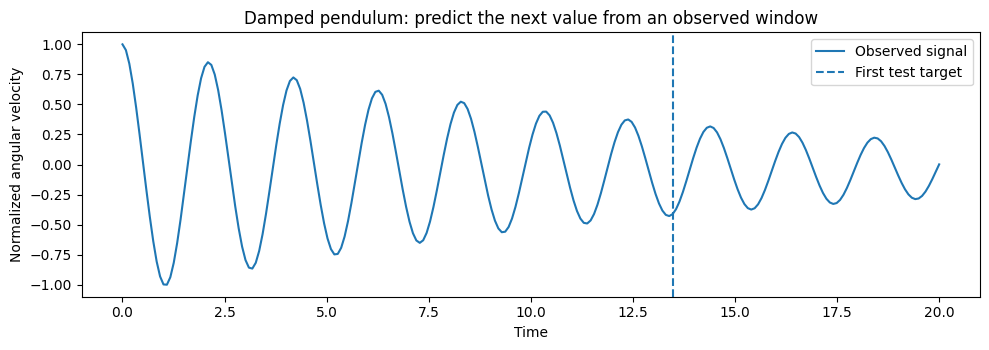

In [ ]:
#@title B2. Generate Data and Check Shapes
x, y = get_damped_shm_data(seq_len=SEQ_LEN)
X = x.double().unsqueeze(-1)       # [sample, time, feature]
Y = y.double().reshape(-1, 1)      # [sample, output]
train_count = int(0.67 * len(X))
assert 0 < train_count < len(X)
X_train, Y_train = X[:train_count], Y[:train_count]
X_test, Y_test = X[train_count:], Y[train_count:]
target_times = data_module.t[SEQ_LEN : SEQ_LEN + len(X)]
assert X.shape == (len(Y), SEQ_LEN, 1)
assert Y.shape == (len(X), 1)
assert len(target_times) == len(Y)
assert X.device.type == "cpu" and X.dtype == torch.float64
print(f"X={tuple(X.shape)}, Y={tuple(Y.shape)}, dtype={X.dtype}, device={X.device}")
print(f"Train={len(X_train)}, test={len(X_test)}; chronological window split")

plt.figure(figsize=(10, 3.6))
plt.plot(data_module.t, data_module.dataset[:, 0], label="Observed signal")
plt.axvline(target_times[train_count], linestyle="--", label="First test target")
plt.xlabel("Time")
plt.ylabel("Normalized angular velocity")
plt.title("Damped pendulum: predict the next value from an observed window")
plt.legend()
plt.tight_layout()
plt.show()

### B3. The Same Model, a Different QNode Backend

`default.qubit` uses Torch backpropagation; both Lightning backends use adjoint differentiation.
This cell runs forward and backward passes on two complete windows and compares the results
with a CPU reference model using identical parameter values.

**This is more than a `torch.cuda.is_available()` check.** Torch's CUDA status does not establish
that cuQuantum executed successfully. If the selected backend fails, the cell stops and reports
the error; it does not silently fall back to CPU.


In [ ]:
#@title B3. Build the Model and Check Gradients (Also a Warm-Up)
np.random.seed(SEED)
torch.manual_seed(SEED)
xb, yb = X_train[:2], Y_train[:2]
try:
    model = FWP(**MODEL_ARGS, backend=BACKEND).double()
    reference = FWP(**MODEL_ARGS, backend="default.qubit").double()
    reference.load_state_dict(model.state_dict(), strict=True)

    sequence = model(xb)
    ref_sequence = reference(xb)
    assert sequence.shape == (SEQ_LEN, len(xb), 1)
    torch.testing.assert_close(sequence, ref_sequence, atol=1e-8, rtol=1e-7)
    loss = nn.functional.mse_loss(sequence[-1], yb)
    ref_loss = nn.functional.mse_loss(ref_sequence[-1], yb)
    loss.backward()
    ref_loss.backward()
    slow_grad_norm = 0.0
    max_grad_error = 0.0
    ref_parameters = dict(reference.named_parameters())
    for name, parameter in model.named_parameters():
        grad = parameter.grad
        ref_grad = ref_parameters[name].grad
        assert grad is not None and ref_grad is not None, f"Missing gradient: {name}"
        assert torch.isfinite(grad).all(), f"Non-finite gradient: {name}"
        torch.testing.assert_close(grad, ref_grad, atol=1e-8, rtol=1e-7)
        max_grad_error = max(max_grad_error, (grad - ref_grad).abs().max().item())
        if "slow_program" in name:
            slow_grad_norm += grad.norm().item()
    assert slow_grad_norm > 0.0, "Slow-program gradient is zero in this check."
except Exception as exc:
    raise RuntimeError(
        f"Selected backend {BACKEND!r} failed the QFWP check. No CPU fallback was run. "
        "Read the underlying error. For an explicit CPU demo, select default.qubit "
        "or lightning.qubit in B1, then rerun B2 onward."
    ) from exc

forward_error = (sequence - ref_sequence).abs().max().item()
model.zero_grad(set_to_none=True)
INITIAL_STATE = {name: tensor.detach().clone() for name, tensor in model.state_dict().items()}
CHECKED_CONFIG = dict(CONFIG)
qnode = model.fwp_cell.q_func.q_func
print("PASS | Actual QNode device:", qnode.device.name)
print("Differentiation:", qnode.diff_method)
print("Sequence output shape:", tuple(sequence.shape))
print(f"Max output error vs CPU: {forward_error:.3e}")
print(f"Max parameter-gradient error vs CPU: {max_grad_error:.3e}")
print(f"Slow-program gradient norm sum: {slow_grad_norm:.3e}")
print("No optimizer update has been performed yet.")
del reference, sequence, ref_sequence, loss, ref_loss

PASS | Actual QNode device: lightning.gpu
Differentiation: adjoint
Sequence output shape: (4, 2, 1)
Max output error vs CPU: 1.307e-09
Max parameter-gradient error vs CPU: 3.991e-09
Slow-program gradient norm sum: 1.044e+00
No optimizer update has been performed yet.


### B4. Optional: Inspect Input-Driven Fast-Weight Updates

This is a forward-only inspection; it does not update the slow-program parameters.
The reported norms illustrate how fast weights accumulate within one window.
They are not measures of training quality.


In [ ]:
#@title B4. Fast-Weight Updates Within One Window
fast = model.fwp_cell.initial_fast_params(1)
with torch.no_grad():
    for step in range(SEQ_LEN):
        one_input = X_train[:1, step, :]
        _, next_fast = model.fwp_cell(one_input, fast)
        print(f"t={step + 1}: x={one_input.item():+.3f}, "
              f"||delta Theta||={(next_fast - fast).norm().item():.3f}, "
              f"||Theta||={next_fast.norm().item():.3f}")
        fast = next_fast

t=1: x=+1.000, ||delta Theta||=0.118, ||Theta||=0.118
t=2: x=+0.952, ||delta Theta||=0.106, ||Theta||=0.224
t=3: x=+0.839, ||delta Theta||=0.084, ||Theta||=0.306
t=4: x=+0.675, ||delta Theta||=0.066, ||Theta||=0.360


## C. Short Training Run | Original Optimizer and Model

Use the original RMSprop settings and sequential minibatches without shuffling.
Inputs and Torch parameters remain CPU `float64` tensors. The default run is only **5 epochs**.
Each epoch records train/test MSE without redrawing the full sequence or saving files.

Training MSE is the sample-weighted average of minibatch losses during optimization—not a fresh
evaluation of the entire training set at the end of the epoch. Test MSE is evaluated after each epoch.

Rerunning C2 restarts training from the initial weights saved in B3; it does not resume the previous run.


In [ ]:
#@title C1. Training and Batched Inference Helpers (Collapsible)
@torch.no_grad()
def predict_last(model, features, batch_size=32):
    was_training = model.training
    model.eval()
    try:
        return torch.cat([
            model(features[i : i + batch_size])[-1]
            for i in range(0, len(features), batch_size)
        ], dim=0)
    finally:
        model.train(was_training)


def train_one_epoch(model, optimizer, features, targets, batch_size):
    model.train()
    squared_error_sum = 0.0
    for start in range(0, len(features), batch_size):
        xb = features[start : start + batch_size]
        yb = targets[start : start + batch_size]
        optimizer.zero_grad(set_to_none=True)
        prediction = model(xb)[-1]
        assert prediction.shape == yb.shape, "Do not broadcast regression targets."
        loss = nn.functional.mse_loss(prediction, yb)
        if not torch.isfinite(loss):
            raise FloatingPointError("Non-finite training loss; inspect the configuration.")
        loss.backward()
        optimizer.step()
        squared_error_sum += loss.detach().item() * len(xb)
    return squared_error_sum / len(features)

In [ ]:
#@title C2. Run Short Training
if CONFIG != CHECKED_CONFIG:
    raise RuntimeError("The configuration has changed. Rerun B2 and B3 before training.")
model.load_state_dict(INITIAL_STATE, strict=True)
optimizer = torch.optim.RMSprop(model.parameters(), lr=LEARNING_RATE,
                                alpha=0.99, eps=1e-8, weight_decay=0,
                                momentum=0, centered=False)
history = {"epoch": [], "train_mse": [], "test_mse": [], "epoch_seconds": []}
training_started = time.perf_counter()
progress = tqdm(range(1, EPOCHS + 1), desc=f"QFWP | {BACKEND}")
for epoch in progress:
    started = time.perf_counter()
    train_mse = train_one_epoch(model, optimizer, X_train, Y_train, BATCH_SIZE)
    test_prediction = predict_last(model, X_test, BATCH_SIZE)
    test_mse = nn.functional.mse_loss(test_prediction, Y_test).item()
    if not np.isfinite(test_mse):
        raise FloatingPointError("Non-finite test MSE.")
    elapsed = time.perf_counter() - started
    history["epoch"].append(epoch)
    history["train_mse"].append(train_mse)
    history["test_mse"].append(test_mse)
    history["epoch_seconds"].append(elapsed)
    progress.set_postfix(train=f"{train_mse:.5f}", test=f"{test_mse:.5f}")
training_seconds = time.perf_counter() - training_started
print(f"Backend: {BACKEND}; completed {len(history['epoch'])} epochs")
print(f"Final test MSE: {history['test_mse'][-1]:.6f}")
print(f"Training + per-epoch test wall time: {training_seconds:.2f} s (not a backend benchmark)")

QFWP | lightning.gpu:   0%|          | 0/5 [00:00<?, ?it/s]

Backend: lightning.gpu; completed 5 epochs
Final test MSE: 0.007582
Training + per-epoch test wall time: 40.86 s (not a backend benchmark)


## D. Results | Plot After Training

The plotted predictions are **one-step-ahead predictions from observed windows**.
Every input window contains actual historical observations; this is not an autonomous rollout
that repeatedly feeds model predictions back as inputs.
A short run is not guaranteed to converge, and these plots do not establish quantum advantage.


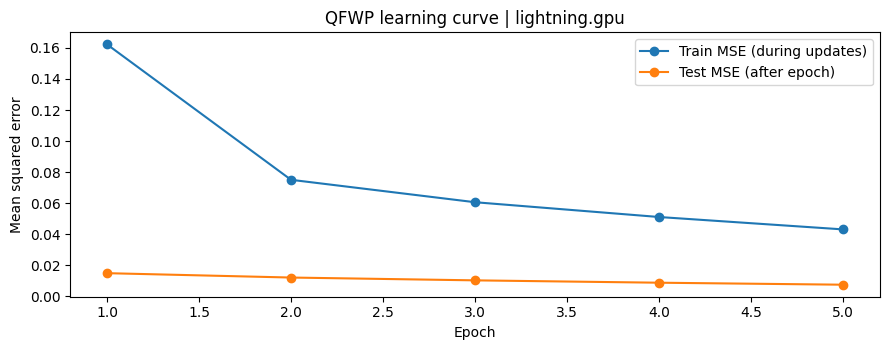

In [ ]:
#@title D1. Learning Curve
loss_figure = plt.figure(figsize=(9, 3.6))
plt.plot(history["epoch"], history["train_mse"], marker="o", label="Train MSE (during updates)")
plt.plot(history["epoch"], history["test_mse"], marker="o", label="Test MSE (after epoch)")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title(f"QFWP learning curve | {BACKEND}")
plt.legend()
plt.tight_layout()
plt.show()

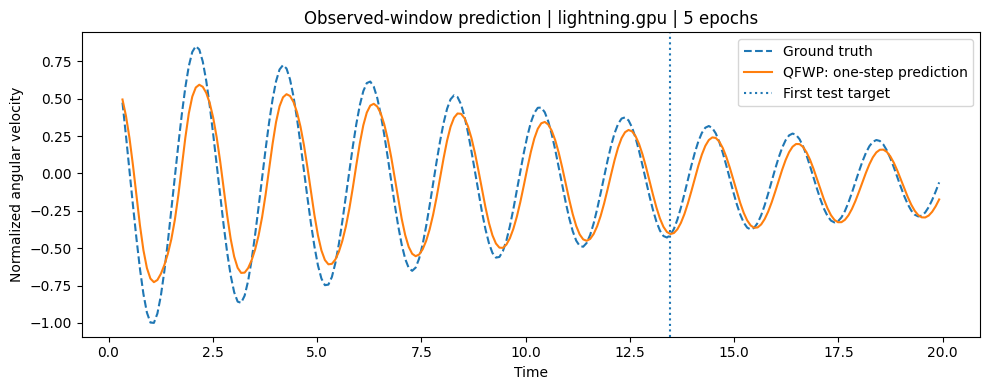

In [ ]:
#@title D2. One-Step Prediction
all_predictions = predict_last(model, X, BATCH_SIZE).cpu().numpy()
truth = Y.cpu().numpy()
prediction_figure = plt.figure(figsize=(10, 4))
plt.plot(target_times, truth[:, 0], linestyle="--", label="Ground truth")
plt.plot(target_times, all_predictions[:, 0], label="QFWP: one-step prediction")
plt.axvline(target_times[train_count], linestyle=":", label="First test target")
plt.xlabel("Time")
plt.ylabel("Normalized angular velocity")
plt.title(f"Observed-window prediction | {BACKEND} | {EPOCHS} epochs")
plt.legend()
plt.tight_layout()
plt.show()

## E. Save the Actual Run | Prepare a Backup Before Presenting

Save the checkpoint, predictions and targets, loss history, environment information, and two PNG plots
once, at the end. Enable the download option only when you are ready to retrieve the result archive.
**No pretrained weights are bundled with this notebook; this section saves your actual execution results.**
Also save a copy of the `.ipynb` with its outputs through Colab's File menu as an offline presentation backup.


In [ ]:
#@title E1. Save Results (Optional Download)
DOWNLOAD_RESULTS = False #@param {type:"boolean"}

run_metadata = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "configuration": CONFIG, "model_arguments": MODEL_ARGS,
    "versions": VERSIONS, "python": sys.version,
    "gpu_report": GPU_REPORT, "training_seconds": training_seconds,
    "actual_backend": model.fwp_cell.q_func.q_func.device.name,
    "target": "normalized angular velocity; one-step observed-window prediction",
    "dataset": "original full-series MinMax scaling and legacy window count preserved",
    "train_count": train_count, "test_count": len(X_test),
}
torch.save({name: value.detach().cpu() for name, value in model.state_dict().items()},
           RESULTS_DIR / "model_state_dict.pt")
(RESULTS_DIR / "metadata.json").write_text(json.dumps(run_metadata, indent=2), encoding="utf-8")
(RESULTS_DIR / "history.json").write_text(json.dumps(history, indent=2), encoding="utf-8")
np.savez(RESULTS_DIR / "predictions.npz", time=target_times, prediction=all_predictions,
         ground_truth=truth, train_count=train_count)
loss_figure.savefig(RESULTS_DIR / "learning_curve.png", dpi=160, bbox_inches="tight")
prediction_figure.savefig(RESULTS_DIR / "prediction.png", dpi=160, bbox_inches="tight")
freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"],
                        capture_output=True, text=True, check=False)
(RESULTS_DIR / "requirements_snapshot.txt").write_text(freeze.stdout, encoding="utf-8")
# Preserve the exact model and data sources used for this run.
for filename in ("qfwp_cuquantum_minimal.py", "damped_shm.py"):
    shutil.copy2(PROJECT_DIR / filename, RESULTS_DIR / filename)
result_archive = shutil.make_archive(str(PROJECT_DIR / "qfwp_demo_results"), "zip", RESULTS_DIR)
print("Saved:", result_archive)
print("Actual backend:", run_metadata["actual_backend"])
if DOWNLOAD_RESULTS:
    try:
        from google.colab import files
    except ImportError:
        print("Outside Colab: use the local archive path printed above.")
    else:
        files.download(result_archive)

Saved: /content/qfwp_demo/qfwp_demo_results.zip
Actual backend: lightning.gpu


## F. Fallbacks and Technical Notes

**GPU unavailable:** explicitly choose `lightning.qubit` or `default.qubit` in B1 and rerun from B2 onward.
The output identifies the actual backend. Do not label a CPU fallback as a GPU demonstration.
If GPU package installation itself fails, set `INSTALL_GPU=False` in A1, rerun the preparation section,
and select a CPU backend.

**Missing CUDA shared library:** inspect the full error message and the driver/package versions first.
Lightning's installation guide also lists dependencies on the CUDA runtime, cuBLAS, cuSPARSE, and nvJitLink.
The following is an example for a CUDA 12 environment—not a command to run unconditionally on every
Colab runtime. Resolve environment issues before presenting:

```python
%pip install nvidia-cuda-runtime-cu12 nvidia-cublas-cu12 nvidia-cusparse-cu12 nvidia-nvjitlink-cu12
```

**Training takes too long:** keep 4 qubits, depth 2, and sequence length 4; use 3–5 epochs for the live run.
For a GPU speedup claim, use a separate benchmark with a fixed workload, matching precision, warm-up,
and repeated measurements. This notebook's elapsed time includes both training and evaluation;
switching to `default.qubit` also changes the differentiation method.

**VM recreated:** rerunning section A recreates the two source files, but it does not restore trained weights.
A notebook saved in Drive is separate from temporary runtime files; save important results explicitly.

**Presentation workflow:** run the entire notebook on the target Colab runtime in advance and save a copy
with its outputs. Present sections B–D live. Clearly label any previously generated results as **pre-run results**.

### Official References

References retained from the original package, which records a check date of **2026-09-15**.
This English edition does not constitute a new compatibility check.

- [Colab FAQ: runtimes, GPU resources, and saving notebooks](https://research.google.com/colaboratory/faq.html)
- [IPython magics: %%writefile](https://ipython.readthedocs.io/en/stable/interactive/magics.html#cellmagic-writefile)
- [Lightning GPU device](https://docs.pennylane.ai/projects/lightning/en/stable/lightning_gpu/device.html)
- [Lightning GPU installation](https://docs.pennylane.ai/projects/lightning/en/stable/lightning_gpu/installation.html)
- [PennyLane 0.45.1](https://pypi.org/project/pennylane/0.45.1/)
- [Lightning GPU 0.45.0](https://pypi.org/project/pennylane-lightning-gpu/0.45.0/)


## G. CPU vs GPU Scaling Benchmark | Forward and Backward Calls

**Fix for Lightning resolving `grad_on_execution=False` back to `True`.**
The previous edition rejected this valid execution configuration before timing anything.
This edition uses **adjoint with `grad_on_execution=True` on both backends**, records
where device derivative calls actually occur, and labels the timing phases accordingly.
No model, dataset, installation, or training cells in sections A–F have been changed.

This optional section benchmarks the **complete QFWP minibatch and time sequence**:
classical slow program, fast-weight updates, QNodes, and classical readout. It creates
fresh models without modifying the trained `model` or its optimizer.
Run **section A, then section G**; training is not a prerequisite.

### What is compared?

| Setting | CPU | GPU |
|---|---|---|
| Backend | `lightning.qubit` | `lightning.gpu` / cuQuantum |
| Differentiation | Adjoint, full Jacobian | Adjoint, full Jacobian |
| Requested gradient scheduling | On execution (`True`) | On execution (`True`) |
| Quantum precision | `complex128` | `complex128` |
| Classical tensors | CPU `float64` | CPU `float64` |
| Parameters and minibatch | Same values at a given size | Same values at a given size |

Both use `device_vjp=False`, `cache=False`, `shots=None`, and first-order differentiation.
Here `cache=False` disables the QNode evaluation cache; it does **not** prevent storing
Jacobians computed during forward for the same graph's backward call.
This is not the separate `default.qubit + backprop` baseline used elsewhere in the notebook.

### Timing definitions — read before interpreting the plots

**Training forward call (including any adjoint precomputation):** wall-clock time for
`sequence = model(xb)` with gradient tracking. With gradients on execution, this call
can include both circuit simulation and computing its Jacobian. **It is not pure inference.**

**Autograd backward call (using saved Jacobians when available):** wall-clock time for
`loss.backward()` on that repetition's fresh graph. A small value does not imply that
quantum derivative computation was cheap or absent: much of it may already be in forward.
Any device derivative calls that also occur here remain part of this measured interval.

**Forward + backward — primary comparison:** sum of the two measured intervals within
one repetition. Summarize these sums rather than adding separate medians. This includes
both calls' work regardless of which call carries the derivative calculation; it is still
specific to the chosen execution schedule, not a universally optimal throughput result.

Loss construction, `zero_grad`, optimizer updates, model construction, correctness checks,
warm-up, plotting, and file I/O are excluded. The sum is not full optimizer-step latency.
Do not mix these results with results from a forced-deferred or device-VJP experiment.

### Checks and experimental controls

Untimed device trackers record derivative activity in forward and backward independently.
An empty backward device tracker is allowed when forward computed the needed Jacobians.
Every trainable parameter must still receive a finite gradient. CPU/GPU outputs and all
parameter gradients must match; gradient settings and the observed derivative phase must
also agree before publishing a paired speedup. A failed GPU point is never replaced by CPU.

Both backends receive warm-up runs; repeated measurements alternate backend order.
GPU timing boundaries synchronize all visible GPUs. These are host wall-clock measurements,
including Python/Torch/interface overhead, intended for a single-GPU Colab runtime.
Batch size, sequence length, depth, readouts, and CPU thread limit stay fixed across the sweep.
Qubit count changes gate count and classical parameter count too: this is full QFWP scaling,
not a hardware-only microbenchmark. Keep other notebook/GPU work idle while measuring.

References: [QNode execution options](https://docs.pennylane.ai/en/stable/code/api/pennylane.QNode.html),
[Lightning CPU configuration](https://docs.pennylane.ai/projects/lightning/en/stable/_modules/pennylane_lightning/lightning_qubit/lightning_qubit.html),
[Lightning GPU configuration](https://docs.pennylane.ai/projects/lightning/en/stable/_modules/pennylane_lightning/lightning_gpu/lightning_gpu.html),
[Jacobian storage and reuse](https://docs.pennylane.ai/en/stable/_modules/pennylane/workflow/jacobian_products.html).


In [ ]:
#@title G1. Benchmark Configuration (Independent of the Training Demo)
import os as _bench_os
import json as _bench_json

RUN_BENCHMARK = True #@param {type:"boolean"}
BENCH_QUBITS_CSV = "4, 8, 12,16,20" #@param {type:"string"}
BENCH_BATCH_SIZE = 4 #@param {type:"integer"}
BENCH_SEQ_LEN = 4 #@param {type:"integer"}
BENCH_DEPTH = 2 #@param {type:"integer"}
BENCH_N_OUTPUTS = 4 #@param {type:"integer"}
BENCH_WARMUP = 2 #@param {type:"integer"}
BENCH_REPEATS = 5 #@param {type:"integer"}
BENCH_CPU_THREADS = 2 #@param {type:"integer"}
BENCH_SEED = 12345 #@param {type:"integer"}
BENCH_RUN_GPU = True #@param {type:"boolean"}
BENCH_MAX_POINT_SECONDS = 120.0 #@param {type:"number"}
BENCH_ALLOW_ABOVE_24_QUBITS = False #@param {type:"boolean"}

try:
    BENCH_QUBITS = sorted({int(part.strip()) for part in BENCH_QUBITS_CSV.split(",") if part.strip()})
except ValueError as exc:
    raise ValueError("Enter comma-separated integer qubit counts, for example: 4, 8, 12, 16, 20") from exc
if not BENCH_QUBITS:
    raise ValueError("At least one qubit count is required.")
for name, value in {"batch size": BENCH_BATCH_SIZE, "sequence length": BENCH_SEQ_LEN,
                    "depth": BENCH_DEPTH, "readouts": BENCH_N_OUTPUTS,
                    "warm-up": BENCH_WARMUP, "repetitions": BENCH_REPEATS,
                    "CPU threads": BENCH_CPU_THREADS}.items():
    if not isinstance(value, int) or value < 1:
        raise ValueError(name + " must be a positive integer.")
if min(BENCH_QUBITS) < BENCH_N_OUTPUTS:
    raise ValueError("Each qubit count must be at least the fixed number of Z readouts.")
if max(BENCH_QUBITS) > 24 and not BENCH_ALLOW_ABOVE_24_QUBITS:
    raise ValueError("Above 24 qubits, explicitly enable the large-state override after checking memory.")
if BENCH_MAX_POINT_SECONDS < 0:
    raise ValueError("The soft point budget must be non-negative; zero disables it.")
BENCH_CONFIG = dict(
    qubits=BENCH_QUBITS, batch_size=BENCH_BATCH_SIZE, seq_len=BENCH_SEQ_LEN,
    depth=BENCH_DEPTH, n_outputs=BENCH_N_OUTPUTS, warmup=BENCH_WARMUP,
    repeats=BENCH_REPEATS, cpu_threads=BENCH_CPU_THREADS, seed=BENCH_SEED,
    run_gpu=BENCH_RUN_GPU, max_point_seconds=float(BENCH_MAX_POINT_SECONDS),
    quantum_dtype="complex128", classical_dtype="float64", classical_device="cpu",
    diff_method="adjoint", grad_on_execution=True, device_vjp=False, cache=False,
    timing_policy="adjoint_on_execution_v2",
    workload="full QFWP minibatch/time sequence; loss on final prediction",
)
print(_bench_json.dumps(BENCH_CONFIG, indent=2))
print("Enable RUN_BENCHMARK to execute G3. G2 only defines helpers.")
print("Start with 4, 8, 12, 16 for a rehearsal; add 20, 22, 24 as resources permit.")
print("Forward includes adjoint precomputation; backward can reuse saved Jacobians.")


{
  "qubits": [
    4,
    8,
    12,
    16,
    20
  ],
  "batch_size": 4,
  "seq_len": 4,
  "depth": 2,
  "n_outputs": 4,
  "warmup": 2,
  "repeats": 5,
  "cpu_threads": 2,
  "seed": 12345,
  "run_gpu": true,
  "max_point_seconds": 120.0,
  "quantum_dtype": "complex128",
  "classical_dtype": "float64",
  "classical_device": "cpu",
  "diff_method": "adjoint",
  "grad_on_execution": true,
  "device_vjp": false,
  "cache": false,
  "timing_policy": "adjoint_on_execution_v2",
  "workload": "full QFWP minibatch/time sequence; loss on final prediction"
}
Enable RUN_BENCHMARK to execute G3. G2 only defines helpers.
Start with 4, 8, 12, 16 for a rehearsal; add 20, 22, 24 as resources permit.
Forward includes adjoint precomputation; backward can reuse saved Jacobians.


### G2. Reproducible Timing Helpers

Run the next cell once, then collapse it. It does not start the sweep.
The helpers use the **same two embedded Python modules**; no third source-file upload is needed.
The temporary CPU thread limit applies to both CPU and GPU runs' classical work and is restored afterward.
Loaded OpenMP/BLAS thread pools and Torch's thread counts are recorded with the results.

The soft point budget is checked **between completed repetition rounds**, including untimed setup in
the point's elapsed time. It cannot interrupt an in-flight native CUDA/C++ call. On reaching the budget,
the sweep keeps completed measurements and does not attempt larger sizes. This is not a hard timeout.
The repeated-sample count in the table is authoritative; a truncated point may have fewer than five samples.

In [ ]:
#@title G2. Benchmark Helpers (Collapsible; No Model Architecture Changes)
import gc
import hashlib
import importlib.metadata as bench_metadata
import json
import math
import numbers
import os
import platform
import shutil
import subprocess
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import torch
import pennylane as qml
from IPython.display import display
try:
    import pandas as pd
    from threadpoolctl import threadpool_info, threadpool_limits
except ImportError as exc:
    raise RuntimeError(
        "Section G needs pandas and threadpoolctl. Run %pip install pandas threadpoolctl, "
        "then rerun this cell. The original sections do not need to be changed."
    ) from exc

import qfwp_cuquantum_minimal as bench_qfwp
from damped_shm import get_damped_shm_data as bench_get_data

_BENCH_METRICS = ("forward", "backward", "forward_backward")
_BENCH_BACKENDS = ("lightning.qubit", "lightning.gpu")
_BENCH_DERIVATIVE_KEYS = (
    "derivatives", "derivative_batches", "execute_and_derivative_batches",
    "vjps", "vjp_batches", "execute_and_vjp_batches",
    "jvps", "jvp_batches", "execute_and_jvp_batches",
)


def bench_sync_gpu():
    """Synchronize every visible device, not only Torch's current device.

    In the intended single-GPU Colab runtime, this is one synchronization.
    Keep this notebook as the only GPU workload. No Torch tensor is moved to CUDA.
    """
    for index in range(torch.cuda.device_count()):
        torch.cuda.synchronize(index)


def bench_make_model(n_qubits, backend, config, state=None):
    # Do not consume the training demo's random-number state.
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(config["seed"] + n_qubits)
        candidate = bench_qfwp.FWP(
            s_dim=1, a_dim=config["n_outputs"], n_qubit=n_qubits,
            n_depth=config["depth"], backend=backend,
        ).double()
    if state is not None:
        candidate.load_state_dict(state, strict=True)
    old_qnode = candidate.fwp_cell.q_func.q_func
    candidate.fwp_cell.q_func.q_func = old_qnode.update(
        diff_method="adjoint", grad_on_execution=True,
        device_vjp=False, cache=False, max_diff=1,
    )
    candidate.train()
    return candidate


def bench_counter_snapshot(tracker):
    return {key: float(value) for key, value in tracker.totals.items()
            if isinstance(value, numbers.Real) and key != "results"}


def bench_check_model(candidate, xb, yb, synchronize):
    """Untimed validation; observe derivative scheduling rather than forcing deferral."""
    qnode = candidate.fwp_cell.q_func.q_func
    sample_weights = candidate.fwp_cell.initial_fast_params(len(xb)).requires_grad_(True)
    resolved = qml.workflow.construct_execution_config(qnode, resolve=True)(
        xb[:, 0, :], sample_weights
    )
    if (resolved.gradient_method != "adjoint"
            or resolved.use_device_gradient is not True
            or resolved.use_device_jacobian_product is not False):
        raise RuntimeError("Expected device adjoint / full-Jacobian execution: " + str(resolved))
    if resolved.grad_on_execution not in (True, False):
        raise RuntimeError("Unresolved gradient scheduling: " + str(resolved))

    candidate.zero_grad(set_to_none=True)
    synchronize()
    with torch.enable_grad():
        with qml.Tracker(qnode.device) as forward_tracker:
            sequence = candidate(xb)
            synchronize()
        forward_counts = bench_counter_snapshot(forward_tracker)
        expected_shape = (xb.shape[1], xb.shape[0], 1)
        if tuple(sequence.shape) != expected_shape or sequence[-1].shape != yb.shape:
            raise RuntimeError(f"Unexpected sequence/target shapes: {sequence.shape}, {yb.shape}")
        loss = torch.nn.functional.mse_loss(sequence[-1], yb)
        with qml.Tracker(qnode.device) as backward_tracker:
            loss.backward()
            synchronize()
        backward_counts = bench_counter_snapshot(backward_tracker)

    forward_derivatives = any(forward_counts.get(k, 0) > 0 for k in _BENCH_DERIVATIVE_KEYS)
    backward_derivatives = any(backward_counts.get(k, 0) > 0 for k in _BENCH_DERIVATIVE_KEYS)
    if not (forward_derivatives or backward_derivatives):
        raise RuntimeError(
            "No backend derivative activity was observed in either phase. "
            "Refusing an unverified gradient benchmark. Trackers: "
            + str({"forward": forward_counts, "backward": backward_counts})
        )
    derivative_phase = (
        "forward_and_backward" if forward_derivatives and backward_derivatives
        else "forward_precompute" if forward_derivatives
        else "backward"
    )
    if not torch.isfinite(sequence).all() or not torch.isfinite(loss):
        raise RuntimeError("Non-finite outputs or loss during the untimed check.")
    gradients = {}
    for name, parameter in candidate.named_parameters():
        if parameter.grad is None or not torch.isfinite(parameter.grad).all():
            raise RuntimeError("Missing/non-finite parameter gradient: " + name)
        gradients[name] = parameter.grad.detach().clone()
    audit = {
        "actual_device": qnode.device.name,
        "gradient_method": resolved.gradient_method,
        "grad_on_execution": bool(resolved.grad_on_execution),
        "use_device_gradient": bool(resolved.use_device_gradient),
        "device_vjp": bool(resolved.use_device_jacobian_product),
        "observed_derivative_phase": derivative_phase,
        "forward_tracker": forward_counts,
        "backward_tracker": backward_counts,
        "timing_note": "Call-boundary timings; forward may precompute Jacobians for backward.",
    }
    return sequence.detach().clone(), gradients, audit


def bench_schedule_signature(audit):
    """Do not publish a paired speedup for different differentiation schedules."""
    return (audit["gradient_method"], audit["grad_on_execution"],
            audit["device_vjp"], audit["observed_derivative_phase"])


def bench_time_step(candidate, xb, yb, synchronize):
    """One fresh graph per repetition; exclude zero_grad and loss construction."""
    candidate.zero_grad(set_to_none=True)
    with torch.enable_grad():
        synchronize()
        t0 = time.perf_counter_ns()
        sequence = candidate(xb)
        synchronize()
        t1 = time.perf_counter_ns()
        loss = torch.nn.functional.mse_loss(sequence[-1], yb)
        synchronize()
        t2 = time.perf_counter_ns()
        loss.backward()
        synchronize()
        t3 = time.perf_counter_ns()
    forward_ms = (t1 - t0) / 1e6
    backward_ms = (t3 - t2) / 1e6
    # No retain_graph, optimizer, .item(), plotting, or file I/O in timed regions.
    return {"forward_ms": forward_ms, "backward_ms": backward_ms,
            "forward_backward_ms": forward_ms + backward_ms}


def bench_summarize(raw_rows):
    raw = pd.DataFrame(raw_rows)
    summary_rows = []
    if not raw.empty:
        for (n_qubits, backend), group in raw.groupby(["n_qubits", "backend"], sort=True):
            row = {"n_qubits": int(n_qubits), "backend": backend,
                   "repetitions": len(group), "n_parameters": int(group.n_parameters.iloc[0]),
                   "one_statevector_MiB": (16 * 2 ** int(n_qubits)) / 2**20,
                   "grad_on_execution": bool(group.grad_on_execution.iloc[0]),
                   "device_vjp": bool(group.device_vjp.iloc[0]),
                   "observed_derivative_phase": str(group.observed_derivative_phase.iloc[0])}
            for metric in _BENCH_METRICS:
                values = group[metric + "_ms"].to_numpy(dtype=float)
                row[metric + "_median_ms"] = float(np.median(values))
                row[metric + "_q25_ms"] = float(np.percentile(values, 25))
                row[metric + "_q75_ms"] = float(np.percentile(values, 75))
            summary_rows.append(row)
    summary = pd.DataFrame(summary_rows)
    speedup_rows = []
    if not summary.empty:
        for n_qubits, group in summary.groupby("n_qubits", sort=True):
            indexed = group.set_index("backend")
            if not all(backend in indexed.index for backend in _BENCH_BACKENDS):
                continue  # Never fabricate missing GPU values or interpolate missing points.
            schedule_columns = ("grad_on_execution", "device_vjp", "observed_derivative_phase")
            if any(indexed.loc["lightning.qubit", key] != indexed.loc["lightning.gpu", key]
                   for key in schedule_columns):
                continue
            row = {"n_qubits": int(n_qubits)}
            for metric in _BENCH_METRICS:
                cpu = float(indexed.loc["lightning.qubit", metric + "_median_ms"])
                gpu = float(indexed.loc["lightning.gpu", metric + "_median_ms"])
                row[metric + "_speedup"] = cpu / gpu
            speedup_rows.append(row)
    return raw, summary, pd.DataFrame(speedup_rows)


def bench_environment():
    versions = {}
    for name in ("pennylane", "pennylane-lightning", "pennylane-lightning-gpu",
                 "custatevec-cu12", "torch", "numpy", "scipy", "pandas", "threadpoolctl"):
        try:
            versions[name] = bench_metadata.version(name)
        except bench_metadata.PackageNotFoundError:
            versions[name] = "not installed"
    gpu_report = "nvidia-smi unavailable"
    if shutil.which("nvidia-smi"):
        try:
            result = subprocess.run(
                ["nvidia-smi", "--query-gpu=name,driver_version,memory.total",
                 "--format=csv,noheader"], capture_output=True, text=True, timeout=15,
            )
            gpu_report = result.stdout.strip() or result.stderr.strip()
        except (OSError, subprocess.TimeoutExpired) as exc:
            gpu_report = str(exc)
    cpu_name = platform.processor()
    try:
        for line in Path("/proc/cpuinfo").read_text().splitlines():
            if line.startswith("model name"):
                cpu_name = line.split(":", 1)[1].strip()
                break
    except OSError:
        pass
    return {"python": sys.version, "platform": platform.platform(), "cpu": cpu_name,
            "logical_cpus": os.cpu_count(),
            "affinity_cpus": len(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity") else None,
            "torch_cuda_available": torch.cuda.is_available(), "torch_cuda_build": torch.version.cuda,
            "torch_interop_threads": torch.get_num_interop_threads(),
            "OMP_NUM_THREADS": os.environ.get("OMP_NUM_THREADS"),
            "gpu_report": gpu_report, "versions": versions}


def bench_checkpoint(result):
    directory = result["directory"]
    raw, summary, speedup = bench_summarize(result["raw_rows"])
    for name, table in (("raw_timings", raw), ("summary", summary), ("speedup", speedup),
                        ("checks", pd.DataFrame(result["checks"])),
                        ("errors_and_skips", pd.DataFrame(result["errors"]))):
        temporary = directory / (name + ".tmp")
        table.to_csv(temporary, index=False)
        temporary.replace(directory / (name + ".csv"))
    metadata = {key: value for key, value in result.items()
                if key not in ("directory", "raw_rows")}
    metadata["raw_sample_count"] = len(result["raw_rows"])
    temporary = directory / "metadata.tmp"
    temporary.write_text(json.dumps(metadata, indent=2, default=str), encoding="utf-8")
    temporary.replace(directory / "metadata.json")


def run_qfwp_benchmark(config):
    # Accept an old G1 configuration in an already-running notebook, but record
    # the corrected policy honestly. Do not mutate the caller's dictionary.
    config = dict(config)
    if config.get("grad_on_execution") is False:
        print("Applying scheduling fix: grad_on_execution=True on both backends.")
    config.update(diff_method="adjoint", grad_on_execution=True,
                  device_vjp=False, cache=False, timing_policy="adjoint_on_execution_v2")
    # Only section A is required. Recreate a fixed, real dataset minibatch here;
    # neither the trained model nor the training demo's optimizer is touched.
    x, y = bench_get_data(seq_len=config["seq_len"])
    if len(x) < config["batch_size"]:
        raise ValueError("The requested minibatch is larger than the available dataset.")
    xb = x[:config["batch_size"]].double().unsqueeze(-1).contiguous()
    yb = y[:config["batch_size"]].double().reshape(-1, 1).contiguous()
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    directory = Path.cwd() / "benchmark_results" / stamp
    directory.mkdir(parents=True, exist_ok=False)
    np.savez(directory / "benchmark_minibatch.npz", X=xb.numpy(), Y=yb.numpy())
    source_hashes = {}
    for module in (bench_qfwp, sys.modules[bench_get_data.__module__]):
        source = Path(module.__file__)
        shutil.copy2(source, directory / source.name)
        source_hashes[source.name] = hashlib.sha256(source.read_bytes()).hexdigest()
    result = {"directory": directory, "config": dict(config), "environment": bench_environment(),
              "source_sha256": source_hashes, "started_at_utc": stamp, "status": "running",
              "raw_rows": [], "checks": [], "audits": [], "errors": [], "thread_pools": []}
    print("Benchmark results directory:", directory)
    print("CPU:", result["environment"]["cpu"])
    print("GPU:", result["environment"]["gpu_report"])
    print("CPU baseline: lightning.qubit; GPU: lightning.gpu; both request adjoint on execution.")
    print("Forward includes adjoint precomputation; backward can reuse saved Jacobians.")
    print("Primary comparison: forward + backward. Phase trackers report the actual schedule.")
    print("Times are per full QFWP minibatch/sequence, not per single circuit or sample.")
    bench_checkpoint(result)
    disabled = {}
    if not config["run_gpu"]:
        disabled["lightning.gpu"] = "GPU explicitly disabled in G1; GPU was not measured."
    elif not torch.cuda.is_available():
        disabled["lightning.gpu"] = (
            "CUDA synchronization is unavailable through this Torch installation/runtime; "
            "GPU was not measured. Select a GPU runtime and verify the CUDA-enabled Torch build."
        )
    else:
        try:
            torch.cuda.init()
            bench_sync_gpu()
        except Exception as exc:
            disabled["lightning.gpu"] = f"CUDA initialization failed: {type(exc).__name__}: {exc}"
    for reason in disabled.values():
        print(reason)
    previous_torch_threads = torch.get_num_threads()
    models = {}
    try:
        torch.set_num_threads(config["cpu_threads"])
        for point_index, n_qubits in enumerate(config["qubits"]):
            started = time.perf_counter()
            models = {}
            cpu_reference = None
            cpu_audit = None
            point_audits = {}
            state = None
            print(f"\n{n_qubits} qubits | one complex128 state vector: "
                  f"{16 * 2**n_qubits / 2**20:.3f} MiB (not peak memory)")
            # Construct both backends before entering threadpool_limits so their
            # already-loaded OpenMP/BLAS libraries are included in the context.
            for backend in _BENCH_BACKENDS:
                if backend in disabled:
                    result["errors"].append({"n_qubits": n_qubits, "backend": backend,
                                             "stage": "skipped", "reason": disabled[backend]})
                    continue
                if backend == "lightning.gpu" and state is None:
                    result["errors"].append({"n_qubits": n_qubits, "backend": backend,
                                             "stage": "skipped", "reason": "No CPU initialization/reference."})
                    continue
                try:
                    candidate = bench_make_model(n_qubits, backend, config, state)
                    models[backend] = candidate
                    if backend == "lightning.qubit":
                        state = {name: value.detach().clone() for name, value in candidate.state_dict().items()}
                        torch.save(state, directory / f"initial_state_{n_qubits}q.pt")
                except Exception as exc:
                    reason = f"{type(exc).__name__}: {exc}"
                    result["errors"].append({"n_qubits": n_qubits, "backend": backend,
                                             "stage": "construction", "reason": reason})
                    disabled[backend] = reason
                    print(backend, "NOT MEASURED:", reason)
            with threadpool_limits(limits=config["cpu_threads"]):
                result["thread_pools"].append({"n_qubits": n_qubits,
                    "torch_threads": torch.get_num_threads(), "pools": threadpool_info()})
                for backend in list(models):
                    synchronize = bench_sync_gpu if backend == "lightning.gpu" else lambda: None
                    try:
                        snapshot = bench_check_model(models[backend], xb, yb, synchronize)
                        outputs, gradients, audit = snapshot
                        audit.update(n_qubits=n_qubits, backend=backend)
                        result["audits"].append(audit)
                        if backend == "lightning.qubit":
                            cpu_reference = (outputs, gradients)
                            cpu_audit = audit
                            output_error = gradient_error = 0.0
                            status = "reference; finite gradients; phase audit passed"
                        else:
                            if cpu_reference is None:
                                raise RuntimeError("No valid CPU reference; refusing unchecked GPU timings.")
                            if bench_schedule_signature(audit) != bench_schedule_signature(cpu_audit):
                                raise RuntimeError(
                                    "CPU/GPU differentiation schedules differ; refusing a paired comparison: "
                                    + str({"CPU": bench_schedule_signature(cpu_audit),
                                           "GPU": bench_schedule_signature(audit)})
                                )
                            ref_output, ref_gradients = cpu_reference
                            torch.testing.assert_close(outputs, ref_output, rtol=1e-7, atol=1e-9)
                            for name, gradient in gradients.items():
                                torch.testing.assert_close(gradient, ref_gradients[name], rtol=1e-6, atol=1e-8)
                            output_error = float((outputs - ref_output).abs().max())
                            gradient_error = max(float((gradients[name] - ref_gradients[name]).abs().max())
                                                 for name in gradients)
                            status = "CPU/GPU outputs and all parameter gradients match; phase audit passed"
                        point_audits[backend] = audit
                        result["checks"].append({"n_qubits": n_qubits, "backend": backend,
                            "grad_on_execution": audit["grad_on_execution"],
                            "observed_derivative_phase": audit["observed_derivative_phase"],
                            "status": status, "max_abs_output_error": output_error,
                            "max_abs_parameter_gradient_error": gradient_error})
                        print(backend, ":", status)
                        print("  Actual grad_on_execution:", audit["grad_on_execution"],
                              "| observed derivative phase:", audit["observed_derivative_phase"])
                        print("  Forward tracker:", audit["forward_tracker"])
                        print("  Backward tracker:", audit["backward_tracker"])
                        for _ in range(config["warmup"]):
                            bench_time_step(models[backend], xb, yb, synchronize)
                    except Exception as exc:
                        reason = f"{type(exc).__name__}: {exc}"
                        result["errors"].append({"n_qubits": n_qubits, "backend": backend,
                                                "stage": "check_or_warmup", "reason": reason})
                        disabled[backend] = reason
                        del models[backend]
                        print(backend, "NOT MEASURED:", reason)
                gc.collect()  # Outside timed regions; keep Python GC enabled normally.
                for repetition in range(config["repeats"]):
                    order = list(models)
                    if (point_index + repetition) % 2:
                        order.reverse()
                    for order_index, backend in enumerate(order):
                        synchronize = bench_sync_gpu if backend == "lightning.gpu" else lambda: None
                        try:
                            measured = bench_time_step(models[backend], xb, yb, synchronize)
                            if not all(math.isfinite(value) and value > 0 for value in measured.values()):
                                raise RuntimeError("Invalid measured time.")
                            result["raw_rows"].append({"n_qubits": n_qubits, "backend": backend,
                                "repetition": repetition + 1, "backend_order": order_index + 1,
                                "n_parameters": sum(p.numel() for p in models[backend].parameters()),
                                "grad_on_execution": point_audits[backend]["grad_on_execution"],
                                "device_vjp": point_audits[backend]["device_vjp"],
                                "observed_derivative_phase": point_audits[backend]["observed_derivative_phase"],
                                **measured})
                        except Exception as exc:
                            reason = f"{type(exc).__name__}: {exc}"
                            result["errors"].append({"n_qubits": n_qubits, "backend": backend,
                                                    "stage": "timing", "reason": reason})
                            disabled[backend] = reason
                            del models[backend]
                            # A failed point is not a valid speedup result.
                            result["raw_rows"] = [row for row in result["raw_rows"]
                                if not (row["n_qubits"] == n_qubits and row["backend"] == backend)]
                            print(backend, "POINT DISCARDED:", reason)
                    bench_checkpoint(result)
                    if not models:
                        break
                    if (config["max_point_seconds"] > 0
                            and time.perf_counter() - started > config["max_point_seconds"]):
                        print("Soft point budget reached; completed rounds are preserved.")
                        break
            point_rows = [row for row in result["raw_rows"] if row["n_qubits"] == n_qubits]
            _, point_summary, _ = bench_summarize(point_rows)
            if not point_summary.empty:
                display(point_summary[["n_qubits", "backend", "repetitions", "forward_median_ms",
                                       "backward_median_ms", "forward_backward_median_ms"]].round(3))
            models.clear()
            candidate = None
            gc.collect()
            bench_checkpoint(result)
            if (config["max_point_seconds"] > 0
                    and time.perf_counter() - started > config["max_point_seconds"]):
                result["status"] = "stopped_before_larger_sizes_due_to_soft_budget"
                break
            if all(backend in disabled for backend in _BENCH_BACKENDS):
                result["status"] = "stopped_no_available_backends"
                break
        if result["status"] == "running":
            result["status"] = "complete_with_errors_or_skips" if result["errors"] else "complete"
    except KeyboardInterrupt:
        result["status"] = "interrupted; only completed measurements retained"
        print("Interrupted. Completed measurements have been preserved.")
    finally:
        models.clear()
        torch.set_num_threads(previous_torch_threads)
        result["finished_at_utc"] = datetime.now(timezone.utc).isoformat()
        bench_checkpoint(result)
        gc.collect()
    print("\nStatus:", result["status"])
    print("Saved measurements, audits, initial weights, source files, and environment to:", directory)
    return result

In [ ]:
#@title G3. Run the Qubit Sweep
if RUN_BENCHMARK:
    BENCH_RESULT = run_qfwp_benchmark(BENCH_CONFIG)
else:
    BENCH_RESULT = None
    print("Benchmark not run. In G1, enable RUN_BENCHMARK, rerun G1, then execute G3 onward.")

Benchmark results directory: /content/qfwp_demo/benchmark_results/20260916T033047_199646Z
CPU: Intel(R) Xeon(R) CPU @ 2.00GHz
GPU: Tesla T4, 580.82.07, 15360 MiB
CPU baseline: lightning.qubit; GPU: lightning.gpu; both request adjoint on execution.
Forward includes adjoint precomputation; backward can reuse saved Jacobians.
Primary comparison: forward + backward. Phase trackers report the actual schedule.
Times are per full QFWP minibatch/sequence, not per single circuit or sample.

4 qubits | one complex128 state vector: 0.000 MiB (not peak memory)
lightning.qubit : reference; finite gradients; phase audit passed
  Actual grad_on_execution: True | observed derivative phase: forward_precompute
  Forward tracker: {'execute_and_derivative_batches': 8.0, 'executions': 32.0, 'derivatives': 32.0}
  Backward tracker: {}
lightning.gpu : CPU/GPU outputs and all parameter gradients match; phase audit passed
  Actual grad_on_execution: True | observed derivative phase: forward_precompute
  Forwar

,n_qubits,backend,repetitions,forward_median_ms,backward_median_ms,forward_backward_median_ms
0,4,lightning.gpu,5,184.726,6.519,191.512
1,4,lightning.qubit,5,52.461,7.035,60.081



8 qubits | one complex128 state vector: 0.004 MiB (not peak memory)
lightning.qubit : reference; finite gradients; phase audit passed
  Actual grad_on_execution: True | observed derivative phase: forward_precompute
  Forward tracker: {'execute_and_derivative_batches': 8.0, 'executions': 32.0, 'derivatives': 32.0}
  Backward tracker: {}
lightning.gpu : CPU/GPU outputs and all parameter gradients match; phase audit passed
  Actual grad_on_execution: True | observed derivative phase: forward_precompute
  Forward tracker: {'execute_and_derivative_batches': 8.0, 'executions': 32.0, 'derivatives': 32.0}
  Backward tracker: {}


,n_qubits,backend,repetitions,forward_median_ms,backward_median_ms,forward_backward_median_ms
0,8,lightning.gpu,5,240.408,8.122,248.41
1,8,lightning.qubit,5,84.306,9.684,93.99



12 qubits | one complex128 state vector: 0.062 MiB (not peak memory)
lightning.qubit : reference; finite gradients; phase audit passed
  Actual grad_on_execution: True | observed derivative phase: forward_precompute
  Forward tracker: {'execute_and_derivative_batches': 8.0, 'executions': 32.0, 'derivatives': 32.0}
  Backward tracker: {}
lightning.gpu : CPU/GPU outputs and all parameter gradients match; phase audit passed
  Actual grad_on_execution: True | observed derivative phase: forward_precompute
  Forward tracker: {'execute_and_derivative_batches': 8.0, 'executions': 32.0, 'derivatives': 32.0}
  Backward tracker: {}


...


16 qubits | one complex128 state vector: 1.000 MiB (not peak memory)
lightning.qubit : reference; finite gradients; phase audit passed
  Actual grad_on_execution: True | observed derivative phase: forward_precompute
  Forward tracker: {'execute_and_derivative_batches': 8.0, 'executions': 32.0, 'derivatives': 32.0}
  Backward tracker: {}
lightning.gpu : CPU/GPU outputs and all parameter gradients match; phase audit passed
  Actual grad_on_execution: True | observed derivative phase: forward_precompute
  Forward tracker: {'execute_and_derivative_batches': 8.0, 'executions': 32.0, 'derivatives': 32.0}
  Backward tracker: {}


,n_qubits,backend,repetitions,forward_median_ms,backward_median_ms,forward_backward_median_ms
0,16,lightning.gpu,5,474.945,12.381,489.551
1,16,lightning.qubit,5,714.170,14.572,728.568



20 qubits | one complex128 state vector: 16.000 MiB (not peak memory)
lightning.qubit : reference; finite gradients; phase audit passed
  Actual grad_on_execution: True | observed derivative phase: forward_precompute
  Forward tracker: {'execute_and_derivative_batches': 8.0, 'executions': 32.0, 'derivatives': 32.0}
  Backward tracker: {}
lightning.gpu : CPU/GPU outputs and all parameter gradients match; phase audit passed
  Actual grad_on_execution: True | observed derivative phase: forward_precompute
  Forward tracker: {'execute_and_derivative_batches': 8.0, 'executions': 32.0, 'derivatives': 32.0}
  Backward tracker: {}
Soft point budget reached; completed rounds are preserved.


,n_qubits,backend,repetitions,forward_median_ms,backward_median_ms,forward_backward_median_ms
0,20,lightning.gpu,4,1769.348,14.144,1784.102
1,20,lightning.qubit,4,17926.088,17.480,17945.920



Status: stopped_before_larger_sizes_due_to_soft_budget
Saved measurements, audits, initial weights, source files, and environment to: /content/qfwp_demo/benchmark_results/20260916T033047_199646Z


### G4. Timing Table and CPU/GPU Speedup

Times are in **milliseconds per full minibatch/sequence**. The primary statistic is the median;
plots show the 25th–75th percentile range (**IQR**, not a confidence interval).
The forward-plus-backward median is calculated from each repetition's sum, not by adding two medians.

$$S(n) = \frac{\operatorname{median}(t_{\rm CPU}(n))}
                   {\operatorname{median}(t_{\rm GPU}(n))}.$$

A ratio above 1 means the GPU was faster in this measured configuration. Below 1 means the CPU was faster.
No ratio is calculated without valid measurements from both backends. Failed GPU execution is reported;
it is never relabeled as a CPU fallback or inserted as a zero-time GPU measurement.

**Use forward + backward as the primary speedup.** The individual forward and backward
columns measure Python call boundaries, not disjoint quantum simulation/derivative kernels.
The forward column can include adjoint Jacobian computation, and backward can reuse it.
Actual scheduling is saved in the checks, audit metadata, and raw timing rows.


In [ ]:
#@title G4. Summarize Measurements and Validation Checks
if BENCH_RESULT is None:
    print("Run G3 first.")
else:
    BENCH_RAW, BENCH_SUMMARY, BENCH_SPEEDUP = bench_summarize(BENCH_RESULT["raw_rows"])
    if BENCH_SUMMARY.empty:
        print("No valid timing samples were collected. Inspect the errors below.")
    else:
        print("Forward: training call incl. adjoint precomputation; backward: autograd call.")
        print("Primary comparison: forward + backward. These are not pure inference/kernel timings.")
        display(BENCH_SUMMARY[[
            "n_qubits", "backend", "repetitions", "n_parameters", "one_statevector_MiB",
            "observed_derivative_phase", "forward_median_ms", "backward_median_ms",
            "forward_backward_median_ms",
        ]].round(4))
    if not BENCH_SPEEDUP.empty:
        print("Speedup = CPU median / GPU median; larger than 1 favors GPU.")
        display(BENCH_SPEEDUP.round(3))
    else:
        print("No complete CPU/GPU pair is available; speedup is not reported.")
    print("Untimed numerical and gradient-scheduling checks:")
    display(pd.DataFrame(BENCH_RESULT["checks"]))
    if BENCH_RESULT["errors"]:
        print("Errors / explicitly skipped measurements:")
        display(pd.DataFrame(BENCH_RESULT["errors"]))
    if not BENCH_SUMMARY.empty and (BENCH_SUMMARY.repetitions < 3).any():
        print("Caution: some points have fewer than three repetitions. Treat their timings as exploratory.")

Forward: training call incl. adjoint precomputation; backward: autograd call.
Primary comparison: forward + backward. These are not pure inference/kernel timings.


,n_qubits,backend,repetitions,n_parameters,one_statevector_MiB,observed_derivative_phase,forward_median_ms,backward_median_ms,forward_backward_median_ms
0,4,lightning.gpu,5,43,0.0002,forward_precompute,184.7262,6.5185,191.5120
1,4,lightning.qubit,5,43,0.0002,forward_precompute,52.4612,7.0347,60.0811
2,8,lightning.gpu,5,111,0.0039,forward_precompute,240.4083,8.1223,248.4103
3,8,lightning.qubit,5,111,0.0039,forward_precompute,84.3062,9.6839,93.9903
4,12,lightning.gpu,5,211,0.0625,forward_precompute,303.7124,10.5424,313.3141
5,12,lightning.qubit,5,211,0.0625,forward_precompute,128.2640,11.6485,140.3810
6,16,lightning.gpu,5,343,1.0000,forward_precompute,474.9446,12.3810,489.5510
7,16,lightning.qubit,5,343,1.0000,forward_precompute,714.1701,14.5717,728.5678
8,20,lightning.gpu,4,507,16.0000,forward_precompute,1769.3481,14.1443,1784.1024
9,20,lightning.qubit,4,507,16.0000,forward_precompute,17926.0878,17.4801,17945.9195


Speedup = CPU median / GPU median; larger than 1 favors GPU.


,n_qubits,forward_speedup,backward_speedup,forward_backward_speedup
0,4,0.284,1.079,0.314
1,8,0.351,1.192,0.378
2,12,0.422,1.105,0.448
3,16,1.504,1.177,1.488
4,20,10.131,1.236,10.059


Untimed numerical and gradient-scheduling checks:


,n_qubits,backend,grad_on_execution,observed_derivative_phase,status,max_abs_output_error,max_abs_parameter_gradient_error
0,4,lightning.qubit,True,forward_precompute,reference; finite gradients; phase audit passed,0.0,0.000000e+00
1,4,lightning.gpu,True,forward_precompute,CPU/GPU outputs and all parameter gradients ma...,0.0,5.551115e-17
2,8,lightning.qubit,True,forward_precompute,reference; finite gradients; phase audit passed,0.0,0.000000e+00
3,8,lightning.gpu,True,forward_precompute,CPU/GPU outputs and all parameter gradients ma...,0.0,2.164935e-15
4,12,lightning.qubit,True,forward_precompute,reference; finite gradients; phase audit passed,0.0,0.000000e+00
5,12,lightning.gpu,True,forward_precompute,CPU/GPU outputs and all parameter gradients ma...,0.0,3.996803e-15
6,16,lightning.qubit,True,forward_precompute,reference; finite gradients; phase audit passed,0.0,0.000000e+00
7,16,lightning.gpu,True,forward_precompute,CPU/GPU outputs and all parameter gradients ma...,0.0,2.926739e-14
8,20,lightning.qubit,True,forward_precompute,reference; finite gradients; phase audit passed,0.0,0.000000e+00
9,20,lightning.gpu,True,forward_precompute,CPU/GPU outputs and all parameter gradients ma...,0.0,2.223131e-12


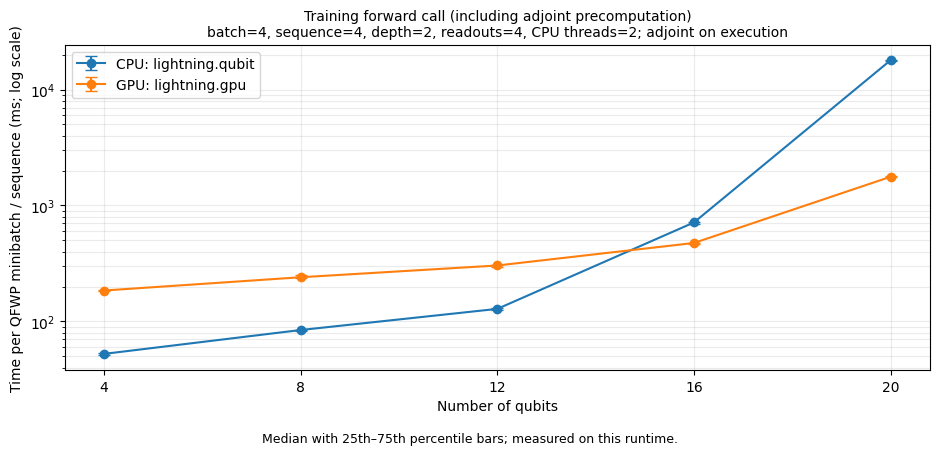

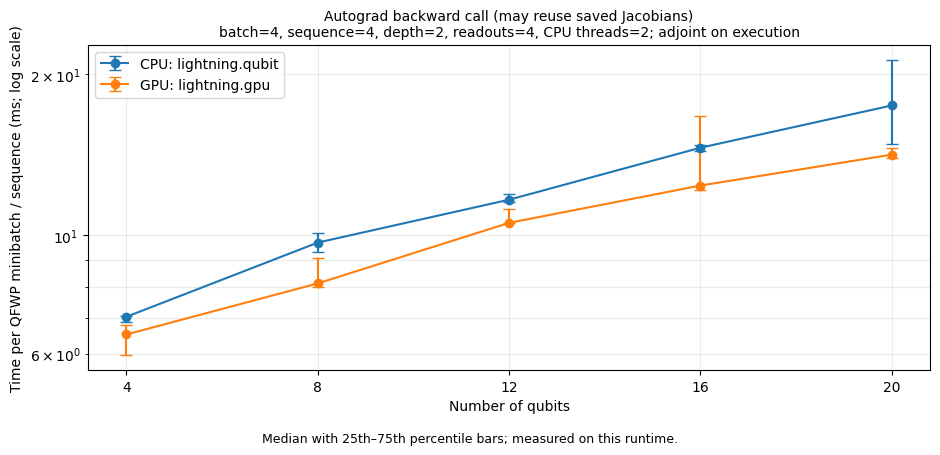

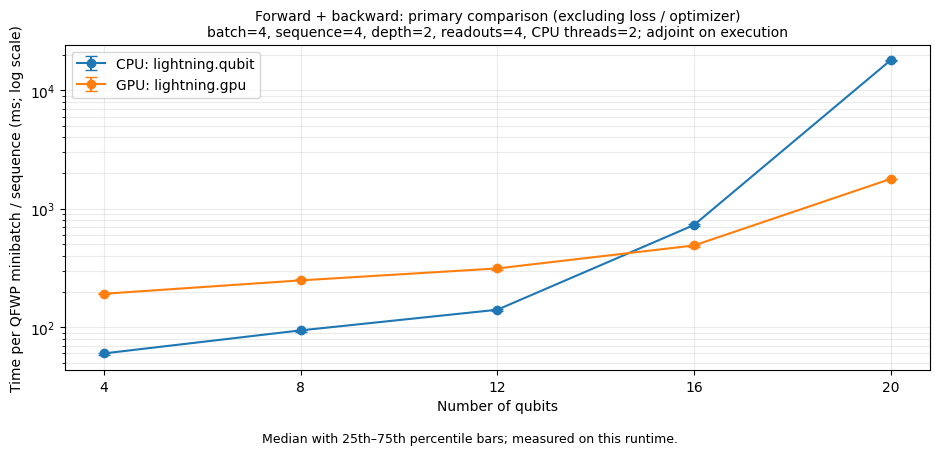

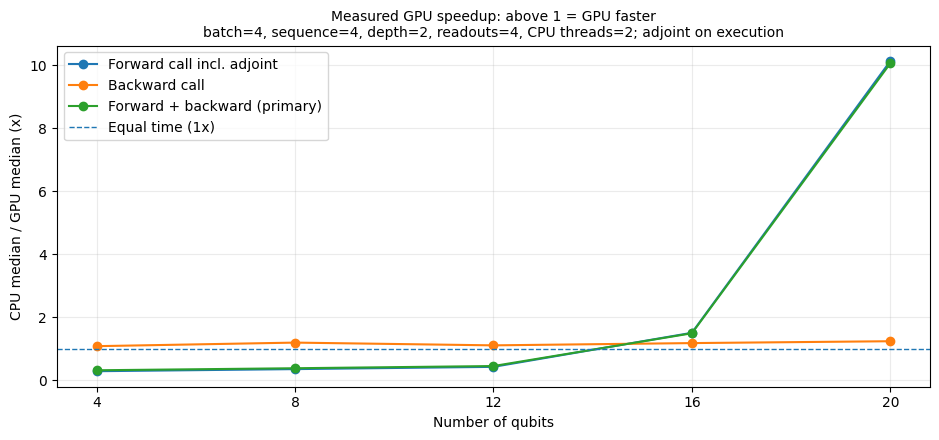

In [ ]:
#@title G5. Plot Forward, Backward, and Combined Times; Then Plot Speedup
import matplotlib.pyplot as plt

BENCH_FIGURES = {}
if BENCH_RESULT is None:
    print("Run G3 first.")
else:
    _raw, _summary, _speedup = bench_summarize(BENCH_RESULT["raw_rows"])
    _cfg = BENCH_RESULT["config"]  # Use the measured configuration, not edited form values.
    _subtitle = (f"batch={_cfg['batch_size']}, sequence={_cfg['seq_len']}, "
                 f"depth={_cfg['depth']}, readouts={_cfg['n_outputs']}, "
                 f"CPU threads={_cfg['cpu_threads']}; adjoint on execution")
    _labels = {"lightning.qubit": "CPU: lightning.qubit", "lightning.gpu": "GPU: lightning.gpu"}
    _titles = {"forward": "Training forward call (including adjoint precomputation)",
               "backward": "Autograd backward call (may reuse saved Jacobians)",
               "forward_backward": "Forward + backward: primary comparison (excluding loss / optimizer)"}
    if _summary.empty:
        print("No timing plots: there are no valid measurements.")
    else:
        for _metric, _title in _titles.items():
            _fig, _ax = plt.subplots(figsize=(9.5, 4.5))
            for _backend in _BENCH_BACKENDS:
                _part = _summary[_summary.backend == _backend].sort_values("n_qubits")
                if _part.empty:
                    continue
                # Reindex to the requested sweep so missing points are gaps, not interpolated lines.
                _part = _part.set_index("n_qubits").reindex(_cfg["qubits"])
                _med = _part[_metric + "_median_ms"].to_numpy(dtype=float)
                _lower = _part[_metric + "_q25_ms"].to_numpy(dtype=float)
                _upper = _part[_metric + "_q75_ms"].to_numpy(dtype=float)
                _ax.errorbar(_cfg["qubits"], _med,
                             yerr=np.vstack([_med - _lower, _upper - _med]),
                             marker="o", capsize=4, label=_labels[_backend])
            _ax.set_yscale("log")
            _ax.set_xticks(_cfg["qubits"])
            _ax.set_xlabel("Number of qubits")
            _ax.set_ylabel("Time per QFWP minibatch / sequence (ms; log scale)")
            _ax.set_title(_title + "\n" + _subtitle, fontsize=10)
            _ax.grid(True, which="both", alpha=0.25)
            _ax.legend()
            _fig.text(0.5, 0.005, "Median with 25th–75th percentile bars; measured on this runtime.",
                      ha="center", fontsize=9)
            _fig.tight_layout(rect=(0, 0.035, 1, 1))
            _fig.savefig(BENCH_RESULT["directory"] / (_metric + "_timing.png"), dpi=160, bbox_inches="tight")
            BENCH_FIGURES[_metric] = _fig
            plt.show()
        if not _speedup.empty:
            _fig, _ax = plt.subplots(figsize=(9.5, 4.5))
            _ratios = _speedup.set_index("n_qubits").reindex(_cfg["qubits"])
            for _metric, _label in (("forward", "Forward call incl. adjoint"), ("backward", "Backward call"),
                                     ("forward_backward", "Forward + backward (primary)")):
                _ax.plot(_cfg["qubits"], _ratios[_metric + "_speedup"], marker="o", label=_label)
            _ax.axhline(1.0, linestyle="--", linewidth=1, label="Equal time (1x)")
            _ax.set_xticks(_cfg["qubits"])
            _ax.set_xlabel("Number of qubits")
            _ax.set_ylabel("CPU median / GPU median (x)")
            _ax.set_title("Measured GPU speedup: above 1 = GPU faster\n" + _subtitle, fontsize=10)
            _ax.grid(True, alpha=0.25)
            _ax.legend()
            _fig.tight_layout()
            _fig.savefig(BENCH_RESULT["directory"] / "cpu_gpu_speedup.png", dpi=160, bbox_inches="tight")
            BENCH_FIGURES["speedup"] = _fig
            plt.show()
        else:
            print("Speedup plot omitted: no valid CPU/GPU measurement pair.")

### G6. Interpretation and Saving

**Small circuits may not benefit from a GPU.** Python/Torch overhead, circuit preparation, transfer,
and GPU launch costs can dominate. The Lightning GPU device is intended for substantial state-vector
workloads; see its [official device page](https://pennylane.ai/devices/lightning-gpu). A crossover depends
on the actual CPU/GPU, batching, readouts, depth, and differentiation settings. Do not assume or force a crossover.

**State-vector size grows exponentially.** One `complex128` state vector occupies $16\times2^n$ bytes.
The table's memory column is only that lower bound: adjoint workspaces, additional states, the classical
model, and runtime allocations increase actual memory. Changing $n$ also changes circuit gate count and
classical model size. GPU speedup here is **classical simulation acceleration**, not quantum advantage.

**Resource failures:** explicit errors and skips are saved. After a backend error, that backend is not
retried at larger sizes in the same sweep; partial results from a failed point are discarded.
A native-process crash or VM loss may still require restarting Colab; Python cannot reliably recover
from every out-of-memory or CUDA error. Completed repetition rounds are checkpointed to the runtime filesystem.
A runtime checkpoint is not persistent storage: download the archive below or copy it to your own storage.

**Presentation:** rehearse the sweep separately, save a notebook with its outputs, and label saved
plots as **pre-run measurements** when using them during the tutorial. Start with `4, 8, 12, 16`;
extend to `20, 22, 24` only after checking resources. Do not run other notebook cells or GPU workloads
concurrently while collecting measurements. A five-repeat tutorial sweep is exploratory, not a comprehensive
performance study.

Each run has a unique directory containing raw timing CSVs, median/IQR summaries, speedup ratios,
validation checks, derivative-scheduling audits, initial parameters at each size, the exact input minibatch,
the two original source files, and environment/thread information. G5 adds four PNG figures when both
backends succeed. Nothing is overwritten in the training demo's results directory.

**Scheduling correction:** this edition no longer requires deferred adjoint. Both QNodes request
`grad_on_execution=True`, and trackers report where derivative work actually occurs. Empty
backward counters are valid when the full Jacobian was already computed in forward. All model
parameters must still have finite gradients; paired CPU/GPU checks remain mandatory.

**Authoring validation:** no benchmark values or generated performance curves are pre-populated.
See `VALIDATION.json` in the package for the actual checks performed; runtime CPU/GPU verification
must be completed on the target installation.

#### Technical references

- [Lightning GPU: cuQuantum and adjoint support](https://docs.pennylane.ai/projects/lightning/en/stable/lightning_gpu/device.html)
- [Lightning CPU simulator](https://pennylane.ai/devices/lightning-qubit)
- [QNode: gradient scheduling, caching, and device VJP](https://docs.pennylane.ai/en/stable/code/api/pennylane.QNode.html)
- [Resolved QNode execution configuration](https://docs.pennylane.ai/en/stable/code/api/pennylane.workflow.construct_execution_config.html)
- [Device tracker instrumentation](https://docs.pennylane.ai/en/stable/code/api/pennylane.devices.modifiers.simulator_tracking.html)
- [Synchronizing CUDA work before timing boundaries](https://docs.pytorch.org/docs/stable/generated/torch.cuda.synchronize.html)

In [ ]:
#@title G6. Save / Download the Benchmark Results
DOWNLOAD_BENCHMARK_RESULTS = False #@param {type:"boolean"}
if BENCH_RESULT is None:
    print("Run G3 first.")
else:
    bench_checkpoint(BENCH_RESULT)
    _directory = BENCH_RESULT["directory"]
    _freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"],
                             capture_output=True, text=True, check=False)
    (_directory / "requirements_snapshot.txt").write_text(_freeze.stdout, encoding="utf-8")
    _archive = shutil.make_archive(str(_directory.parent / ("qfwp_benchmark_" + _directory.name)),
                                   "zip", _directory)
    print("Benchmark archive:", _archive)
    print("Status:", BENCH_RESULT["status"])
    if DOWNLOAD_BENCHMARK_RESULTS:
        try:
            from google.colab import files
        except ImportError:
            print("Outside Colab: use the archive path above.")
        else:
            files.download(_archive)

Run G3 first.



## Beyond This Tutorial: Exploring the QFWP Family

The implementation in this notebook is a starting point for a broader research program developed through my work and collaborations on **Quantum Fast Weight Programmers (QFWPs)**.

The central idea is to learn not only a predictor, but also a mechanism that **programs the predictor as new information arrives**. In temporal QFWP models, evolving fast weights serve as memory: previous observations influence the parameters used to process the current input.

Our subsequent work explores several complementary questions: How can the programmer itself become more parameter-efficient? How should the model regulate what it writes and remembers? Can the same programming principle extend to quantum measurements, quantum-inspired architectures, and adaptive decision-making?

The following overview covers selected published papers and publicly released preprints. These are research extensions and further reading; they are **not additional models implemented by this notebook**.

### 1. The Starting Point: Memory in Circuit Parameters

In the original QFWP [1], a classical slow programmer produces an input-dependent update to the parameters of a variational quantum circuit:

$$
\Delta_t = \ell_t r_t^{\mathsf T},
\qquad
\Theta_t = \Theta_{t-1} + \Delta_t.
$$

The quantum circuit then processes the input using the accumulated parameters $\Theta_t$. Temporal information is therefore carried by a **classically represented circuit-parameter matrix**, rather than requiring a coherent quantum state to persist between time steps.

The slow programmer's trainable parameters are optimized across training examples, while the fast parameters evolve within each input sequence. This separation between **learning the update mechanism** and **applying the learned updates** is the foundation of the family.

### 2. Core QFWP Extensions

| Model or direction | Main question | Key idea |
|---|---|---|
| **Original QFWP** [1] | Can a quantum model learn temporal dependencies through changing circuit parameters? | Accumulate input-dependent, low-rank updates to the fast variational circuit. |
| **Quantum-Train QFWP (QT-QFWP)** [2] | Can we reduce the number of independently trained parameters in the slow programmer? | Use Quantum-Train to generate the classical programmer's neural-network weights through a compact quantum-based parameterization. |
| **Self-Modulating QFWP** [3] | Can the model learn how to regulate both incoming information and existing memory? | Introduce separate input-dependent modulation matrices for new updates and accumulated fast weights. |
| **QFWP with Bounded Memory Gates** [4] | How can we limit repeated amplification along the memory path? | Apply a bounded, sign-preserving `tanh` transformation to the old-state multiplier while preserving the new-update mechanism. |

Here, **QT means Quantum-Train**, not Quantum Transformer.

For the memory-focused extensions, the transition from additive accumulation to self-modulation can be written as

$$
\Theta_t
=
M_t^{\mathrm{old}} \odot \Theta_{t-1}
+
M_t^{\mathrm{new}} \odot \Delta_t,
$$

where $\odot$ denotes element-wise multiplication. The **Only-New** and **Only-Old** variants isolate the roles of writing new information and controlling accumulated memory.

The bounded-memory extension replaces the old-state multiplier with

$$
\widetilde{M}_t^{\mathrm{old}}
=
\tanh\!\left(M_t^{\mathrm{old}}\right).
$$

This prevents the recurrent multiplier from geometrically amplifying a stored contribution. It does not, by itself, impose a bound on arbitrary new additive updates.

Together, these models shift the question from **“How do we accumulate information?”** to **“How do we learn what to write, retain, suppress, or transform?”**

### 3. Related Branches of Fast-Weight Programming

**Programming quantum measurements.**  
In *Learning to Program Quantum Measurements for Machine Learning* [5], the programming principle extends beyond circuit rotation parameters to input-conditioned quantum observables. A neural network dynamically specifies a trainable Hermitian observable, allowing the model to adapt **what it measures**, not only how it prepares or transforms a quantum state. This is a related programmable-QML direction rather than simply another temporal update rule.

**Scalable quantum-inspired programmers.**  
*Gated QKAN-FWP* [6] combines fast-weight programming with Quantum-inspired Kolmogorov–Arnold Networks, whose learnable nonlinear functions are constructed from single-qubit data re-uploading circuits. It investigates QKAN-based slow and/or fast programmers together with gated parameter updates. This branch explores a different architecture from the multi-qubit fast circuit used in this notebook.

**Coordinate-wise memory control.**  
*Complementary Matrix-Gated QKAN Fast-Weight Programmers* [7] extends the QKAN-based branch with element-wise memory regulation. A sigmoid matrix gate controls retention, while its complement controls the new proposal. This allows different fast-weight coordinates to use different retention–write balances, while preserving a coordinate-wise convex update and an affine structure compatible with parallel prefix-scan evaluation.

**Memory-aware reinforcement learning.**  
*Titans-QFWP* [8] integrates QFWP with Titans-style persistence, surprise, and forgetting mechanisms in a hybrid reinforcement-learning architecture for portfolio optimization. It explores how fast-weight memory can support adaptive decisions in a changing environment, extending the discussion beyond supervised forecasting.

### 4. Applications and Systems-Level Evaluation

Architectural changes should be evaluated together with their computational consequences.

Our related studies include **time-series prediction** [9], **parameter-efficient network traffic-matrix forecasting** [10], and a **system-oriented comparison of batched QLSTM and QFWP training** [11]. The latter examines accuracy and component-wise execution times under an equal-trainable-parameter-count setup.

The CPU–GPU benchmark in this notebook addresses a narrower question: **how the execution cost of the original QFWP implementation changes with the simulation backend and qubit count**. It is not a reproduction of all these papers, and its timing results should not be transferred automatically to other QFWP variants.

### 5. Where to Go Next

For readers continuing from this tutorial, the most direct architectural progression is:

**Original QFWP → Self-Modulating QFWP → Bounded Memory Gates**

This progression keeps the fast quantum-circuit backbone recognizable while changing how temporal memory is updated.

QT-QFWP offers a complementary route through programmer parameterization. QKAN-FWP and complementary matrix gating explore alternative computational building blocks and finer-grained memory control. Programmable measurements and Titans-QFWP extend the programming principle toward adaptive readout and decision-making.

> **The broader lesson is that a quantum learning model need not use the same circuit parameters or measurement rule for every input. Learning how to program these components—and how to regulate their evolution—opens a family of models rather than a single architecture.**

### References and Further Reading

**[1] Original QFWP**  
Samuel Yen-Chi Chen, *Learning to Program Variational Quantum Circuits with Fast Weights*. IJCNN 2024.  
[Paper](https://arxiv.org/abs/2402.17760) · [Original implementation](https://github.com/ycchen1989/Quantum_FWP)

**[2] QT-QFWP**  
Chen-Yu Liu et al., *Programming Variational Quantum Circuits with Quantum-Train Agent*. QCNC 2025; preprint released in 2024.  
[Paper](https://arxiv.org/abs/2412.01173)

**[3] Self-Modulating QFWP**  
Samuel Yen-Chi Chen et al., *Self-Modulating Quantum Fast-Weight Programmers for Efficient Adaptive Sequential Learning*. Public preprint, 2026.  
[Paper](https://arxiv.org/abs/2606.24933)

**[4] Bounded Memory Gates**  
Kuo-Chung Peng et al., *Stable Self-Modulating Quantum Fast-Weight Programmers with Bounded Memory Gates*. Public preprint, 2026.  
[Paper](https://arxiv.org/abs/2607.02363)

**[5] Programmable Quantum Measurements**  
Samuel Yen-Chi Chen et al., *Learning to Program Quantum Measurements for Machine Learning*. QCE 2025.  
[Paper](https://arxiv.org/abs/2505.13525)

**[6] Gated QKAN-FWP**  
Kuo-Chung Peng et al., *Gated QKAN-FWP: Scalable Quantum-inspired Sequence Learning*. Public preprint, 2026.  
[Paper](https://arxiv.org/abs/2605.06734)

**[7] Complementary Matrix Gating**  
Kuo-Chung Peng et al., *Complementary Matrix-Gated QKAN Fast-Weight Programmers for Quantum Dynamics Forecasting*. Public preprint, 2026.  
[Paper](https://arxiv.org/abs/2607.27945)

**[8] Titans-QFWP**  
Ming-Kai Hung et al., *Titans-QFWP: A Regime-Aware Hybrid Quantum Fast Weight Programmer for Portfolio Optimization*. Public preprint, 2026; accepted for presentation at the QCE 2026 QCRL Workshop.  
[Paper](https://arxiv.org/abs/2608.29093)

**[9] Time-Series Prediction**  
Andrea Ceschini, Antonello Rosato, Massimo Panella, and Samuel Yen-Chi Chen, *Quantum Fast Weight Programming for Time Series Prediction*. ICASSP 2026.  
[IEEE publication](https://ieeexplore.ieee.org/document/11461293/)

**[10] Traffic-Matrix Forecasting**  
Kuo-Chung Peng et al., *Parameter-Efficient Quantum-Inspired Fast Weight Programmers for Traffic-Matrix Forecasting*. Public preprint, 2026.  
[Paper](https://arxiv.org/abs/2606.27821)

**[11] Batched Training and Systems Evaluation**  
Jun-Hao Chen, Ming-Kai Hung, Yun-Cheng Tsai, and Samuel Yen-Chi Chen, *Batched Training for QLSTM vs. QFWP: A System-Oriented Approach to EPC-Aware RMSE-DA*. ICASSP 2026; preprint released in 2025.  
[Paper](https://arxiv.org/abs/2512.21820)